# B-Scan Migration Playground — Subwavelength FluidFlow TimeLapse Analysis

**Purpose:** Quantify the lateral movement detection limit of a moving fluid front through 
a subwavelength thick fracture using gprMax simulations.

## Geometry

## Migration methods (all post-stack / zero-offset)
| Method | Domain | Velocity use |
|--------|--------|---------------|

## Sensitivity sweep
The fluid front moves w.r.t. a baseline study to create the timelapsed study. The fluid front moves laterally by a fraction of the wavelength in the medium (2 lambda to 1/32 lambda). After migration the sensitivity of is determined if this movement can be detected. Both migration before and after taking the timelapse difference is tested.

In [1]:
import os, time as _time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

In [2]:
# ── Auto-save all figures to TimeLapse_Figures ───────────────────────────────
import pathlib, re as _re, matplotlib.pyplot as _plt

FIGURES_DIR = pathlib.Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Figures\FluidFlow_Study')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

_fig_counter = [0]
_orig_show   = _plt.show

def _autosave_show(*args, **kwargs):
    for fignum in _plt.get_fignums():
        fig = _plt.figure(fignum)
        _fig_counter[0] += 1
        title = ''
        if fig._suptitle:
            title = fig._suptitle.get_text()
        elif fig.axes:
            title = fig.axes[0].get_title()
        title_1line = title.split('\n')[0]
        safe = _re.sub(r'[^\w\s-]', '', title_1line)[:60].strip().replace(' ', '_')
        stem = (f'{_fig_counter[0]:03d}_' + safe) if safe else f'{_fig_counter[0]:03d}'
        path = FIGURES_DIR / ('FF_' + stem + '.png')
        fig.savefig(path, dpi=150, bbox_inches='tight')
        print(f'  [saved] {path.name}')
    _orig_show(*args, **kwargs)

_plt.show = _autosave_show

In [3]:
# Medium
eps_r_ice      = 3.15 # ice
eps_r_air      = 1.0  # air
eps_r_water    = 80.0 # water

v_ice      = 0.299792458 / np.sqrt(eps_r_ice)   # m/ns ≈ 0.16892
v_water    = 0.299792458 / np.sqrt(eps_r_water) # m/ns ≈ 0.03357
f_c_GHz    = 1.5                              # centre frequency [GHz]
wavelength_ice = v_ice / f_c_GHz                  # m ≈ 0.1126
wavelength_water = v_water / f_c_GHz          # m ≈ 0.02238
v_mig      = v_ice / 2                        # exploding-reflector half-velocity [m/ns]
t0_ns      = np.sqrt(2) / f_c_GHz            # Ricker peak delay [ns] ≈ 0.943

# Survey geometry
domain_x   = 4.0
n_traces   = 380
trace_step = 0.01   # m
rx_offset  = 0.1    # m (source-receiver offset in .in file)
x_traces   = (0.1 + rx_offset / 2) + np.arange(n_traces) * trace_step   # midpoints [m]

# Scatterer geometry (shared across all datasets)
x_centre        = domain_x / 2
y_surface       = 0.9                          # air-ice interface [m from bottom]
y_scatterer     = y_surface - wavelength_ice * 6  # cylinder centre [m from bottom]
z_scatterer     = y_surface - y_scatterer     # depth below surface [m] ≈ 0.676
fracture_thickness     = wavelength_ice / 40             # radius of cylinder (point scatterer approximation) [m] ≈ 0.0028
z_top           = z_scatterer - fracture_thickness   # depth to cylinder top (first reflection)

shift = np.array([2, 1, 0.5, 0.25, 0.125, 0.0625, 0.03125]) * wavelength_ice
labels      = ['Baseline', '2λ', '1λ', '½λ', '¼λ', '⅛λ', '¹⁄₁₆λ', '¹⁄₃₂λ']

# Migration depth grid
z_img = np.linspace(0.0, 0.8, 160)

# Paths
STUDY_ROOT = Path(r'C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study')

print(f'λ_ice       = {wavelength_ice*1e3:.1f} mm')
print(f'λ_water     = {wavelength_water*1e3:.1f} mm')
print(f'v_ice       = {v_ice:.5f} m/ns,  v_mig = {v_mig:.5f} m/ns')
print(f't0_ns       = {t0_ns:.3f} ns')
print(f'z_scatterer = {z_scatterer:.3f} m  (centre),  z_top = {z_top:.4f} m')
print(f'x_traces    : {x_traces[0]:.3f} → {x_traces[-1]:.3f} m  ({n_traces} traces)')

λ_ice       = 112.6 mm
λ_water     = 22.3 mm
v_ice       = 0.16891 m/ns,  v_mig = 0.08446 m/ns
t0_ns       = 0.943 ns
z_scatterer = 0.676 m  (centre),  z_top = 0.6728 m
x_traces    : 0.150 → 3.940 m  (380 traces)


# Input File Creation

## Calculate Geometry Factors

In [4]:
separation = np.array([0, 2, 1, 1/2, 1/4, 1/8, 1/16, 1/32]) * wavelength_ice  # m

x_centre = domain_x / 2
x_scatterer_1 = np.round(x_centre - wavelength_ice * 3 + separation, 3) # 8 locations, scatterer that moves
x_scatterer_2 = np.round(x_centre - wavelength_ice * 3, 3) # old scatterer location, fixed

# check if discretisation is sufficient for CFL
dx_required = (v_water / 4.5) / 10 # 4 GHz is the highest frequency component in the Ricker wavelet
if 0.0005 < dx_required:
    print(f"Discretisation is sufficiently small")
else:
    print(f"Discretisation is too large for stability (dx should be < {dx_required:.4f} m)")
if fracture_thickness < dx_required:
    print(f"Scatterer radius is smaller than discretisation")
else:
    print(f"Scatterer radius is sufficiently large for stability (should be > {dx_required:.4f} m)")

Discretisation is sufficiently small
Scatterer radius is sufficiently large for stability (should be > 0.0007 m)


## Background model (no scatterers)

In [5]:
%%writefile fluidflow_study/background/background.in

#title: GPR Fluidflow Study - background
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
 
// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 background n
#messages: y

Overwriting fluidflow_study/background/background.in


# Baseline (static fluid front)

In [6]:
%%writefile fluidflow_study/baseline/resolution_baseline.in

#title: GPR Fluidflow Study - baseline
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Fracture with two phases
#box: 0 0.2212 0 4 0.224 0.001 water
#box: 1.662 0.2212 0 4 0.224 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 baseline n
#messages: y

Overwriting fluidflow_study/baseline/resolution_baseline.in


## 2 $\lambda$ lateral shift

In [7]:
%%writefile fluidflow_study/shift_2lambda/resolution_2lambda.in

#title: GPR Fluidflow Study - 2 wavelength shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice 

// Fracture with two phases
#box: 0 0.2212 0 4 0.224 0.001 water
#box: 1.887 0.2212 0 4 0.224 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 fluid_front_2_lambda n
#messages: y

Overwriting fluidflow_study/shift_2lambda/resolution_2lambda.in


## 1 $\lambda$ lateral shift

In [8]:
%%writefile fluidflow_study/shift_1lambda/resolution_1lambda.in

#title: GPR Fluidflow Study - 1 wavelength shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Fracture with two phases
#box: 0 0.2212 0 4 0.224 0.001 water
#box: 1.775 0.2212 0 4 0.224 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 fluid_front_1_lambda n
#messages: y

Overwriting fluidflow_study/shift_1lambda/resolution_1lambda.in


## 1/2 $\lambda$ lateral shift

In [9]:
%%writefile fluidflow_study/shift_0p5lambda/resolution_0p5lambda.in

#title: GPR Fluidflow Study - 0.5 wavelength shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Fracture with two phases
#box: 0 0.2212 0 4 0.224 0.001 water
#box: 1.718 0.2212 0 4 0.224 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 fluid_front_0p5_lambda n
#messages: y

Overwriting fluidflow_study/shift_0p5lambda/resolution_0p5lambda.in


## 1/4 $\lambda$ lateral shift

In [10]:
%%writefile fluidflow_study/shift_0p25lambda/resolution_0p25lambda.in

#title: GPR Fluidflow Study - 0.25 wavelength shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Fracture with two phases
#box: 0 0.2212 0 4 0.224 0.001 water
#box: 1.690 0.2212 0 4 0.224 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 fluid_front_0p25_lambda n
#messages: y

Overwriting fluidflow_study/shift_0p25lambda/resolution_0p25lambda.in


## 1/8 $\lambda$ lateral shift

In [11]:
%%writefile fluidflow_study/shift_0p125lambda/resolution_0p125lambda.in

#title: GPR Fluidflow Study - 0.125 wavelength shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Fracture with two phases
#box: 0 0.2212 0 4 0.224 0.001 water
#box: 1.676 0.2212 0 4 0.224 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 fluid_front_0p125_lambda n
#messages: y

Overwriting fluidflow_study/shift_0p125lambda/resolution_0p125lambda.in


## 1/16 $\lambda$ lateral shift

In [12]:
%%writefile fluidflow_study/shift_0p0625lambda/resolution_0p0625lambda.in

#title: GPR Fluidflow Study - 0.0625 wavelength shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Fracture with two phases
#box: 0 0.2212 0 4 0.224 0.001 water
#box: 1.669 0.2212 0 4 0.224 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 fluid_front_0p0625_lambda n
#messages: y

Overwriting fluidflow_study/shift_0p0625lambda/resolution_0p0625lambda.in


## 1/32 $\lambda$ lateral shift

In [13]:
%%writefile fluidflow_study/shift_0p03125lambda/resolution_0p03125lambda.in

#title: GPR Fluidflow Study - 0.03125 wavelength shift
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 4.000 0.900 0.001 ice

// Fracture with two phases
#box: 0 0.2212 0 4 0.224 0.001 water
#box: 1.666 0.2212 0 4 0.224 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.900, 0, 'my_ricker')
rx(curr_x + 0.1, 0.900, 0)
#end_python:



#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 fluid_front_0p03125_lambda n
#messages: y

Overwriting fluidflow_study/shift_0p03125lambda/resolution_0p03125lambda.in


# Trial

In [14]:
%%writefile fluidflow_study/trial.in

#title: GPR Fluidflow Study - baseline (Adjusted Geometry)
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model extended to domain ceiling
#box: 0.0 0.0 0.0 4.000 1.000 0.001 ice

// Fracture with two phases
#box: 0.0 0.221 0.0 4.000 0.224 0.001 water
#box: 1.662 0.221 0.0 4.000 0.224 0.001 air

#python:
from gprMax.input_cmd_funcs import *

iteration = current_model_run - 1

# Calculate current x-position
curr_x = 0.100 + (iteration * 0.01)

# Placed antennas safely embedded inside the ice domain (z = 0.850)
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.850, 0, 'my_ricker')
rx(curr_x + 0.100, 0.850, 0)
#end_python:

#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 baseline n
#messages: y

Overwriting fluidflow_study/trial.in


In [15]:
%%writefile fluidflow_study/wetting.in

#title: GPR Fluidflow Study - Graded Transitional Wetting Zone
#domain: 4.000 1.000 0.001
#dx_dy_dz: 0.001 0.001 0.001
#time_window: 20e-9
#pml_cells: 10 10 0 10 10 0

#material: 3.15 1e-6 1.0 0 ice
#material: 1.0 0.0 1.0 0.0 air
#material: 80.0 0.01 1.0 0.0 water

// Intermediate grading materials mimicking a capillary fringe
#material: 50.0 0.008 1.0 0.0 wet_zone_50
#material: 25.0 0.005 1.0 0.0 wet_zone_25
#material: 10.0 0.002 1.0 0.0 wet_zone_10
#material: 4.0  0.0005 1.0 0.0 wet_zone_4

// Subsurface background model (Corrected: extended safely to domain ceiling)
#box: 0.0 0.0 0.0 4.000 1.000 0.001 ice

// Fracture Geometry with 10 cm Transitional Wetting Zone (Thickness = 2.8 mm)
// Phase 1: Pure Water
#box: 0.000 0.2212 0.0 1.612 0.2240 0.001 water

// Graded transition blocks (each 2 cm wide along the profile)
#box: 1.612 0.2212 0.0 1.632 0.2240 0.001 wet_zone_50
#box: 1.632 0.2212 0.0 1.652 0.2240 0.001 wet_zone_25
#box: 1.652 0.2212 0.0 1.672 0.2240 0.001 wet_zone_10
#box: 1.672 0.2212 0.0 1.692 0.2240 0.001 wet_zone_4

// Phase 2: Pure Air
#box: 1.692 0.2212 0.0 4.000 0.2240 0.001 air


#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position (1 cm survey steps)
curr_x = 0.100 + (iteration * 0.01)

# Place antennas safely embedded inside the ice domain (z = 0.850)
waveform('ricker', 1.0, 1.5e9, 'my_ricker')
hertzian_dipole('z', curr_x, 0.850, 0, 'my_ricker')
rx(curr_x + 0.100, 0.850, 0)
#end_python:


#geometry_view: 0 0 0 4.000 1.000 0.001 0.001 0.001 0.001 transition_view n
#messages: y

Overwriting fluidflow_study/wetting.in


# Generating Geometry Files and Merged B-scans
Only uncomment and run when necessary

In [16]:
# input_baseline      = r'fluidflow_study/baseline/resolution_baseline.in'
# input_lambda_2      = r'fluidflow_study/shift_2lambda/resolution_2lambda.in'
# input_lambda_1      = r'fluidflow_study/shift_1lambda/resolution_1lambda.in'
# input_lambda_0p5    = r'fluidflow_study/shift_0p5lambda/resolution_0p5lambda.in'
# input_lambda_0p25   = r'fluidflow_study/shift_0p25lambda/resolution_0p25lambda.in'
# input_lambda_0p125  = r'fluidflow_study/shift_0p125lambda/resolution_0p125lambda.in'
# input_lambda_0p0625 = r'fluidflow_study/shift_0p0625lambda/resolution_0p0625lambda.in'
# input_lambda_0p03125 = r'fluidflow_study/shift_0p03125lambda/resolution_0p03125lambda.in'

# api(input_lambda_2, n=1, geometry_only=True)
# api(input_lambda_1, n=1, geometry_only=True)
# api(input_lambda_0p5, n=1, geometry_only=True)
# api(input_lambda_0p25, n=1, geometry_only=True)
# api(input_lambda_0p125, n=1, geometry_only=True)
# api(input_lambda_0p0625, n=1, geometry_only=True)
# api(input_lambda_0p03125, n=1, geometry_only=True)


In [17]:
# filename_background    = r'fluidflow_study/background/background'
# filename_baseline      = r'fluidflow_study/baseline/resolution_baseline'
# filename_lambda_2      = r'fluidflow_study/shift_2lambda/resolution_2lambda'
# filename_lambda_1      = r'fluidflow_study/shift_1lambda/resolution_1lambda'
# filename_lambda_0p5    = r'fluidflow_study/shift_0p5lambda/resolution_0p5lambda'
# filename_lambda_0p25   = r'fluidflow_study/shift_0p25lambda/resolution_0p25lambda'
# filename_lambda_0p125  = r'fluidflow_study/shift_0p125lambda/resolution_0p125lambda'
# filename_lambda_0p0625 = r'fluidflow_study/shift_0p0625lambda/resolution_0p0625lambda'
# filename_lambda_0p03125 = r'fluidflow_study/shift_0p03125lambda/resolution_0p03125lambda'

# merge_files(filename_background, removefiles=True)
# merge_files(filename_baseline, removefiles=True)
# merge_files(filename_lambda_2, removefiles=True)
# merge_files(filename_lambda_1, removefiles=True)
# merge_files(filename_lambda_0p5, removefiles=True)
# merge_files(filename_lambda_0p25, removefiles=True)
# merge_files(filename_lambda_0p125, removefiles=True)
# merge_files(filename_lambda_0p0625, removefiles=True)
# merge_files(filename_lambda_0p03125, removefiles=True)


In [18]:
# rxnumber    = 1
# rxcomponent = 'Ez'

# output_trial, dt = get_output_data(
#     'fluidflow_study/trial_merged.out', rxnumber, rxcomponent
# )

# output_wetting, dt = get_output_data(
#     'fluidflow_study/wetting_merged.out', rxnumber, rxcomponent
# )

In [19]:
# output_trial[:2000] = 0
# output_wetting[:2000] = 0

In [20]:
# plt.imshow(output_trial, aspect='auto', cmap='seismic', vmin=-100, vmax=100)
# plt.show()
# plt.imshow(output_wetting, aspect='auto', cmap='seismic', vmin=-100, vmax=100)
# plt.show()


# Loading in the data and removing direct wave

In [5]:
rxnumber    = 1
rxcomponent = 'Ez'

output_background, dt = get_output_data(
    'fluidflow_study/background/background_merged.out', rxnumber, rxcomponent
)

output_baseline, _ = get_output_data(
    'fluidflow_study/baseline/resolution_baseline_merged.out', rxnumber, rxcomponent
)

_paths = [
    'fluidflow_study/baseline/resolution_baseline_merged.out',
    'fluidflow_study/shift_2lambda/resolution_2lambda_merged.out',
    'fluidflow_study/shift_1lambda/resolution_1lambda_merged.out',
    'fluidflow_study/shift_0p5lambda/resolution_0p5lambda_merged.out',
    'fluidflow_study/shift_0p25lambda/resolution_0p25lambda_merged.out',
    'fluidflow_study/shift_0p125lambda/resolution_0p125lambda_merged.out',
    'fluidflow_study/shift_0p0625lambda/resolution_0p0625lambda_merged.out',
    'fluidflow_study/shift_0p03125lambda/resolution_0p03125lambda_merged.out',
]
raw_outputs      = [get_output_data(p, rxnumber, rxcomponent)[0] for p in _paths]
outputs_static   = [r - output_background for r in raw_outputs]      # background-subtracted

dt_ns   = dt * 1e9
n_t     = outputs_static[0].shape[0]
time_ns = np.arange(n_t) * dt_ns

# Convenience lists for the visualisation cells below
data_pre = [('Background', output_background)] + list(zip(labels, raw_outputs))
data_static = list(zip(labels, outputs_static))
labels_all = list(labels)           # all 7 labels (Baseline + 7 shifts)
labels = labels[1:]

print(f'dt = {dt_ns:.6f} ns,  n_t = {n_t},  t_max = {time_ns[-1]:.2f} ns')
print(f'Data shape (n_t × n_tr): {outputs_static[0].shape}  ({n_t} time samples × {n_traces} traces)')

dt = 0.002359 ns,  n_t = 8481,  t_max = 20.00 ns
Data shape (n_t × n_tr): (8481, 380)  (8481 time samples × 380 traces)


# Visualisation

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9256\4265967765.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  [saved] FF_001_GPR_B-Scans__Background_Baseline_and_TimeLapsed_Models.png


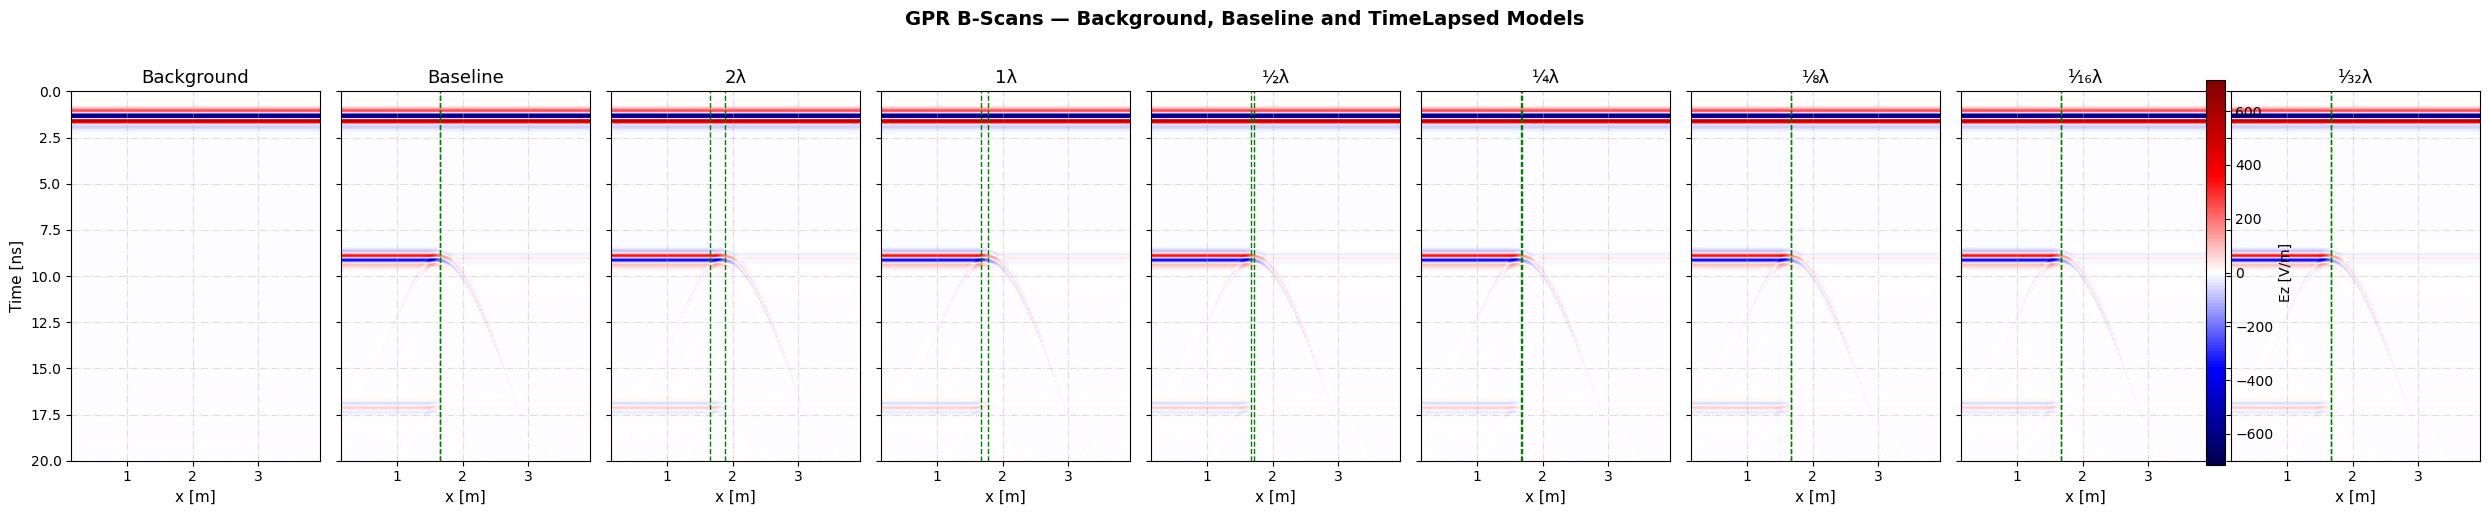

In [6]:
extent_bscan = [x_traces[0], x_traces[-1], time_ns[-1], 0]

fig, axes = plt.subplots(1, 9, figsize=(25, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data_pre)

for i, (ax, (title, d)) in enumerate(zip(axes, data_pre)):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x [m]', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=11)
    ax.grid(linestyle='-.', alpha=0.4)
    if i > 0:  # skip Background panel (no scatterers)
        ax.axvline(x_scatterer_1[i - 1], color='green', linestyle='--', linewidth=1)
        ax.axvline(x_scatterer_2, color='green', linestyle='--', linewidth=1)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans — Background, Baseline and TimeLapsed Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_9256\1430283231.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  [saved] FF_002_GPR_B-Scans__Background_Subtracted.png


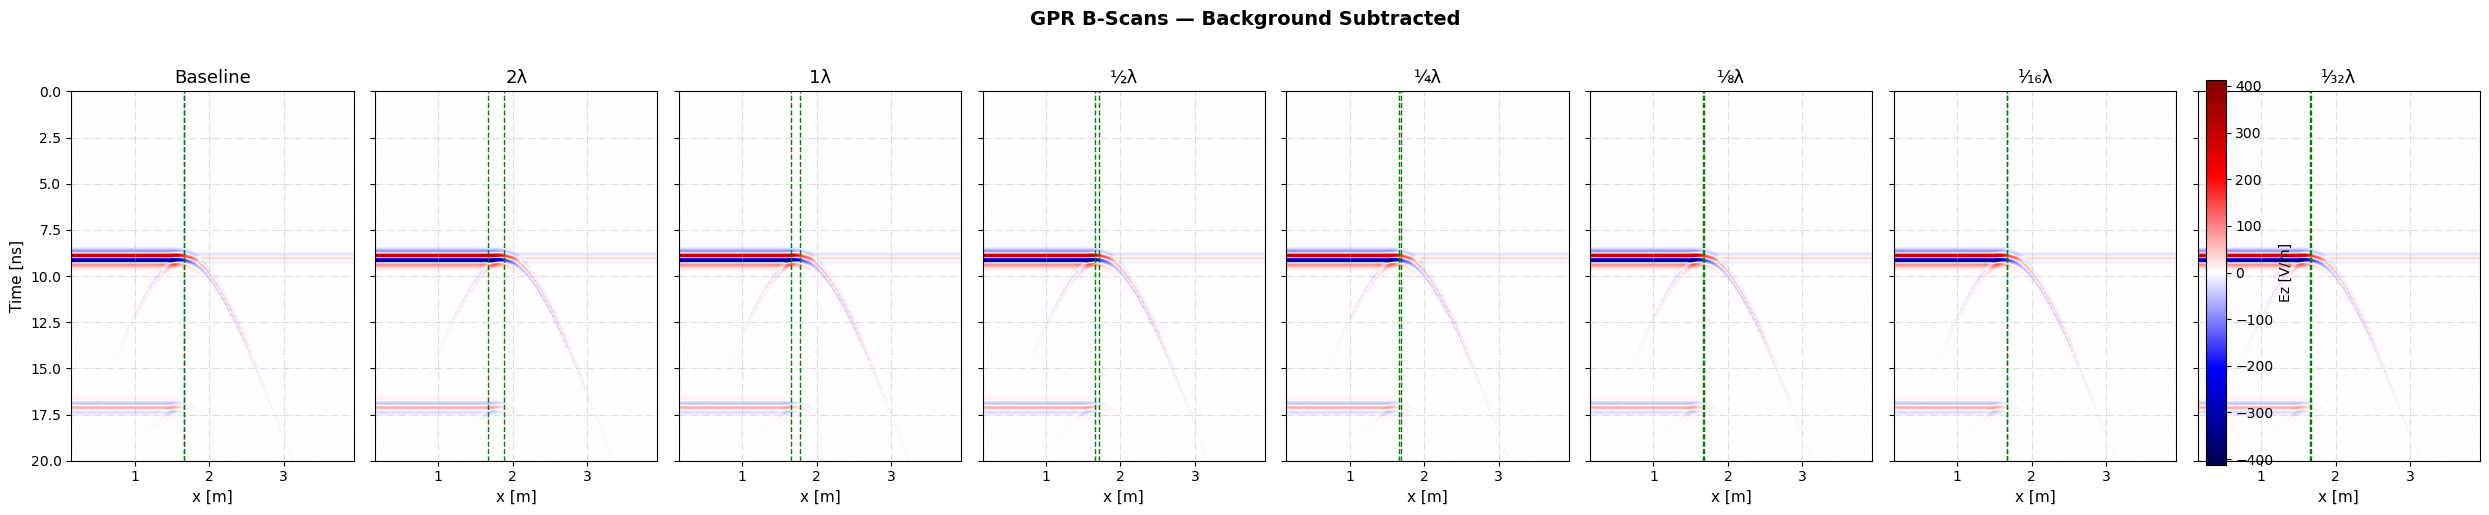

In [7]:
fig, axes = plt.subplots(1, 8, figsize=(25, 5), facecolor='w', sharey=True)
vmax = max(np.abs(d).max() for _, d in data_static)

for i, (ax, (title, d)) in enumerate(zip(axes, data_static)):
    im = ax.imshow(d, aspect='auto', cmap='seismic', extent=extent_bscan,
                   interpolation='nearest', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('x [m]', fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel('Time [ns]', fontsize=11)
    ax.grid(linestyle='-.', alpha=0.4)
    ax.axvline(x_scatterer_1[i], color='green', linestyle='--', linewidth=1)
    ax.axvline(x_scatterer_2, color='green', linestyle='--', linewidth=1)

fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='Ez [V/m]')
fig.suptitle('GPR B-Scans — Background Subtracted', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Kirchhoff Migration

Delay-and-sum migration via the **PyLops zero-offset Kirchhoff operator**.  
Each dataset is preprocessed (tapering + t0 shift — see cell above) before being migrated.  
Green stars mark the true cylinder-top positions.

In [8]:
import sys, pathlib
_here = pathlib.Path.cwd()
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))
from helper_functions.migration import PylopsKirchoffMigration, gazdag_migration, write_backprop_files

## Tapering & t0 Shift

Two pre-processing steps applied to every B-scan before migration:

| Step | Purpose |
|------|---------|
| **Exponential decay taper** (`taper_decay_ns`) | Suppresses late arrivals, emphasises hyperbola apices |
| **Cosine end taper** (`taper_end_ns`) | Zeros the final portion of each trace to remove hyperbola tails |
| **t0 shift** | Removes the Ricker wavelet's built-in peak delay so that t = 0 aligns with the surface |

Adjust the parameters in the cell below and re-run to see their effect on the B-scan.

  [saved] FF_003_Effect_of_Tapering_and_t0_Shift__2λ_dataset_single_trace.png


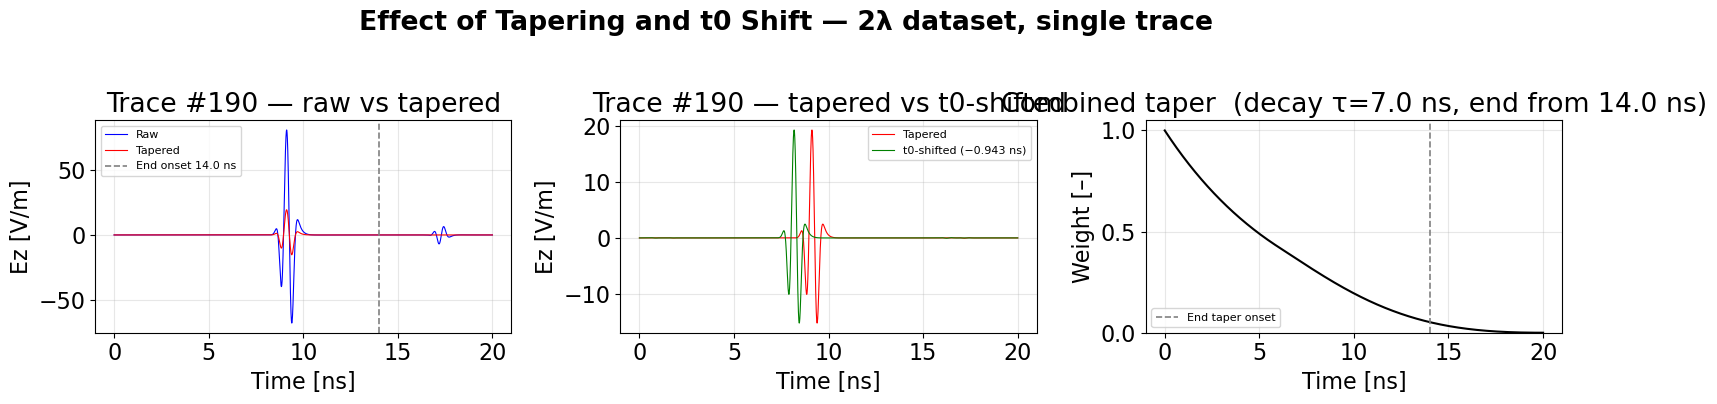

  [saved] FF_004_B-scan_effect_of_tapering_and_t0_shift__2λ_dataset.png


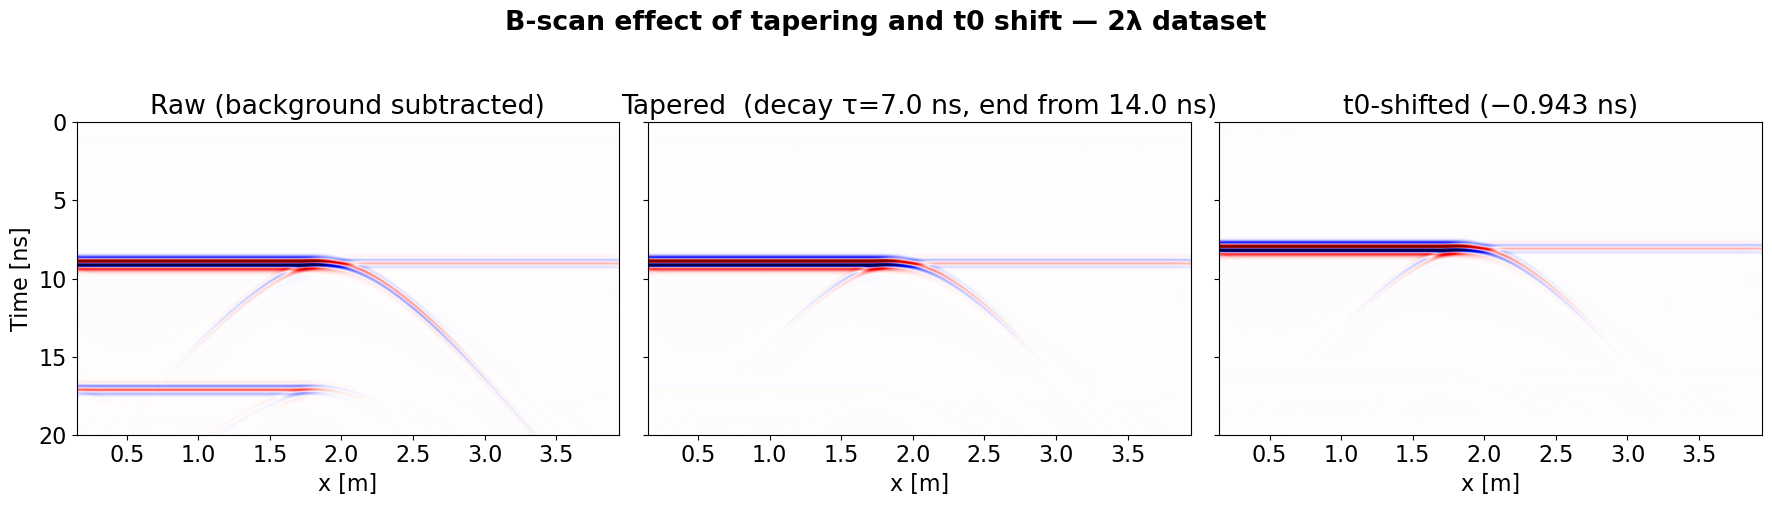

In [9]:
# ── Taper & t0-shift parameters ───────────────────────────────────────────────
taper_end_ns   = 14.0   # cosine ramp onset [ns]: zeros hyperbola tails beyond this time
taper_decay_ns = 7.0    # exponential decay time constant [ns]: de-emphasises late arrivals
ANGLE_AP       = 40     # Kirchhoff aperture half-angle [degrees]

# ── Functions ─────────────────────────────────────────────────────────────────
def make_end_taper(n_samples, taper_samples):
    """Unity everywhere, then half-cosine 1→0 over the last `taper_samples`."""
    win = np.ones(n_samples)
    if taper_samples > 0:
        ramp = 0.5 * (1 + np.cos(np.pi * np.arange(taper_samples) / taper_samples))
        win[-taper_samples:] = ramp
    return win

def make_decay_taper(time_ns, tau_ns):
    """Exponential decay starting at 1.0 (t=0) with time constant tau_ns."""
    return np.exp(-time_ns / tau_ns)

def preprocess(data_nt_ntr, dt_ns, t0_ns, time_ns):
    """
    Prepare a B-scan for Kirchhoff migration.
    Input:  data_nt_ntr  (n_t, n_tr)  — background-subtracted B-scan
    Returns tapered (n_tr, n_t) and t0-shifted (n_tr, n_t) arrays.
    """
    bscan   = data_nt_ntr.T.copy()                              # → (n_tr, n_t)
    n_t     = bscan.shape[1]
    w_end   = make_end_taper(n_t, int(round(taper_end_ns / dt_ns)))
    w_decay = make_decay_taper(time_ns, taper_decay_ns)
    tapered = bscan * (w_end * w_decay)[np.newaxis, :]
    t0_samp = int(round(t0_ns / dt_ns))
    shifted = np.roll(tapered, -t0_samp, axis=1)
    shifted[:, -t0_samp:] = 0.0
    return tapered, shifted

# ── Visualise effect on the 2λ dataset ────────────────────────────────────────
_demo = outputs_static[1]    # (n_t, n_tr) — 2λ background-subtracted
_raw_tr, _shifted = preprocess(_demo, dt_ns, t0_ns, time_ns)
_tapered = _raw_tr   # preprocess returns tapered as first output

w_end_vis   = make_end_taper(n_t, int(round(taper_end_ns   / dt_ns)))
w_decay_vis = make_decay_taper(time_ns, taper_decay_ns)
taper_combined = w_end_vis * w_decay_vis

mid_tr = n_traces // 2   # representative central trace

# --- Row 1: single-trace before/after ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(time_ns, _demo[:, mid_tr], 'b', lw=0.8, label='Raw')
axes[0].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[0].axvline(taper_end_ns, color='gray', ls='--', lw=1.2, label=f'End onset {taper_end_ns} ns')
axes[0].set(xlabel='Time [ns]', ylabel='Ez [V/m]', title=f'Trace #{mid_tr} — raw vs tapered')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(time_ns, _tapered[mid_tr], 'r', lw=0.8, label='Tapered')
axes[1].plot(time_ns, _shifted[mid_tr], 'g', lw=0.8, label=f't0-shifted (−{t0_ns:.3f} ns)')
axes[1].set(xlabel='Time [ns]', ylabel='Ez [V/m]', title=f'Trace #{mid_tr} — tapered vs t0-shifted')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(time_ns, taper_combined, 'k', lw=1.5)
axes[2].axvline(taper_end_ns, color='gray', ls='--', lw=1.2, label=f'End taper onset')
axes[2].set(xlabel='Time [ns]', ylabel='Weight [–]',
            title=f'Combined taper  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)',
            ylim=(0, 1.05))
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.suptitle('Effect of Tapering and t0 Shift — 2λ dataset, single trace', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

# --- Row 2: full B-scan comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
kw = dict(aspect='auto', cmap='seismic', extent=extent_bscan, origin='upper')

vmax0 = np.max(np.abs(_demo)) * 0.5
axes[0].imshow(_demo, **kw, vmin=-vmax0, vmax=vmax0)
axes[0].set(title='Raw (background subtracted)', xlabel='x [m]', ylabel='Time [ns]')

vmax1 = np.max(np.abs(_tapered)) * 0.5
axes[1].imshow(_tapered.T, **kw, vmin=-vmax1, vmax=vmax1)
axes[1].set(title=f'Tapered  (decay τ={taper_decay_ns} ns, end from {taper_end_ns} ns)', xlabel='x [m]')

vmax2 = np.max(np.abs(_shifted)) * 0.5
axes[2].imshow(_shifted.T, **kw, vmin=-vmax2, vmax=vmax2)
axes[2].set(title=f't0-shifted (−{t0_ns:.3f} ns)', xlabel='x [m]')

plt.suptitle('B-scan effect of tapering and t0 shift — 2λ dataset', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [10]:
# ── Kirchhoff migration on all 8 datasets ─────────────────────────────────────────
migrated = {}

for label, raw in zip(labels_all, outputs_static):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Kirchhoff ...', end=' ', flush=True)
    t0 = _time.perf_counter()
    img = PylopsKirchoffMigration(
        shifted, time_ns, x_traces, v_ice, z_img,
        f0=f_c_GHz, angleaperture=ANGLE_AP
    )
    print(f'{_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated[label] = img


[Baseline] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
3.2 s  shape=(160, 380)
[2λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
2.9 s  shape=(160, 380)
[1λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
3.0 s  shape=(160, 380)
[½λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
3.0 s  shape=(160, 380)
[¼λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
3.0 s  shape=(160, 380)
[⅛λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
3.0 s  shape=(160, 380)
[¹⁄₁₆λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
3.3 s  shape=(160, 380)
[¹⁄₃₂λ] Running Kirchhoff ... d.shape: (3222780,) K dimension: (3222780, 60800)
3.7 s  shape=(160, 380)


  [saved] FF_005_Kirchhoff_Migration__All_8_Datasets____f_c15_GHz____aperture.png


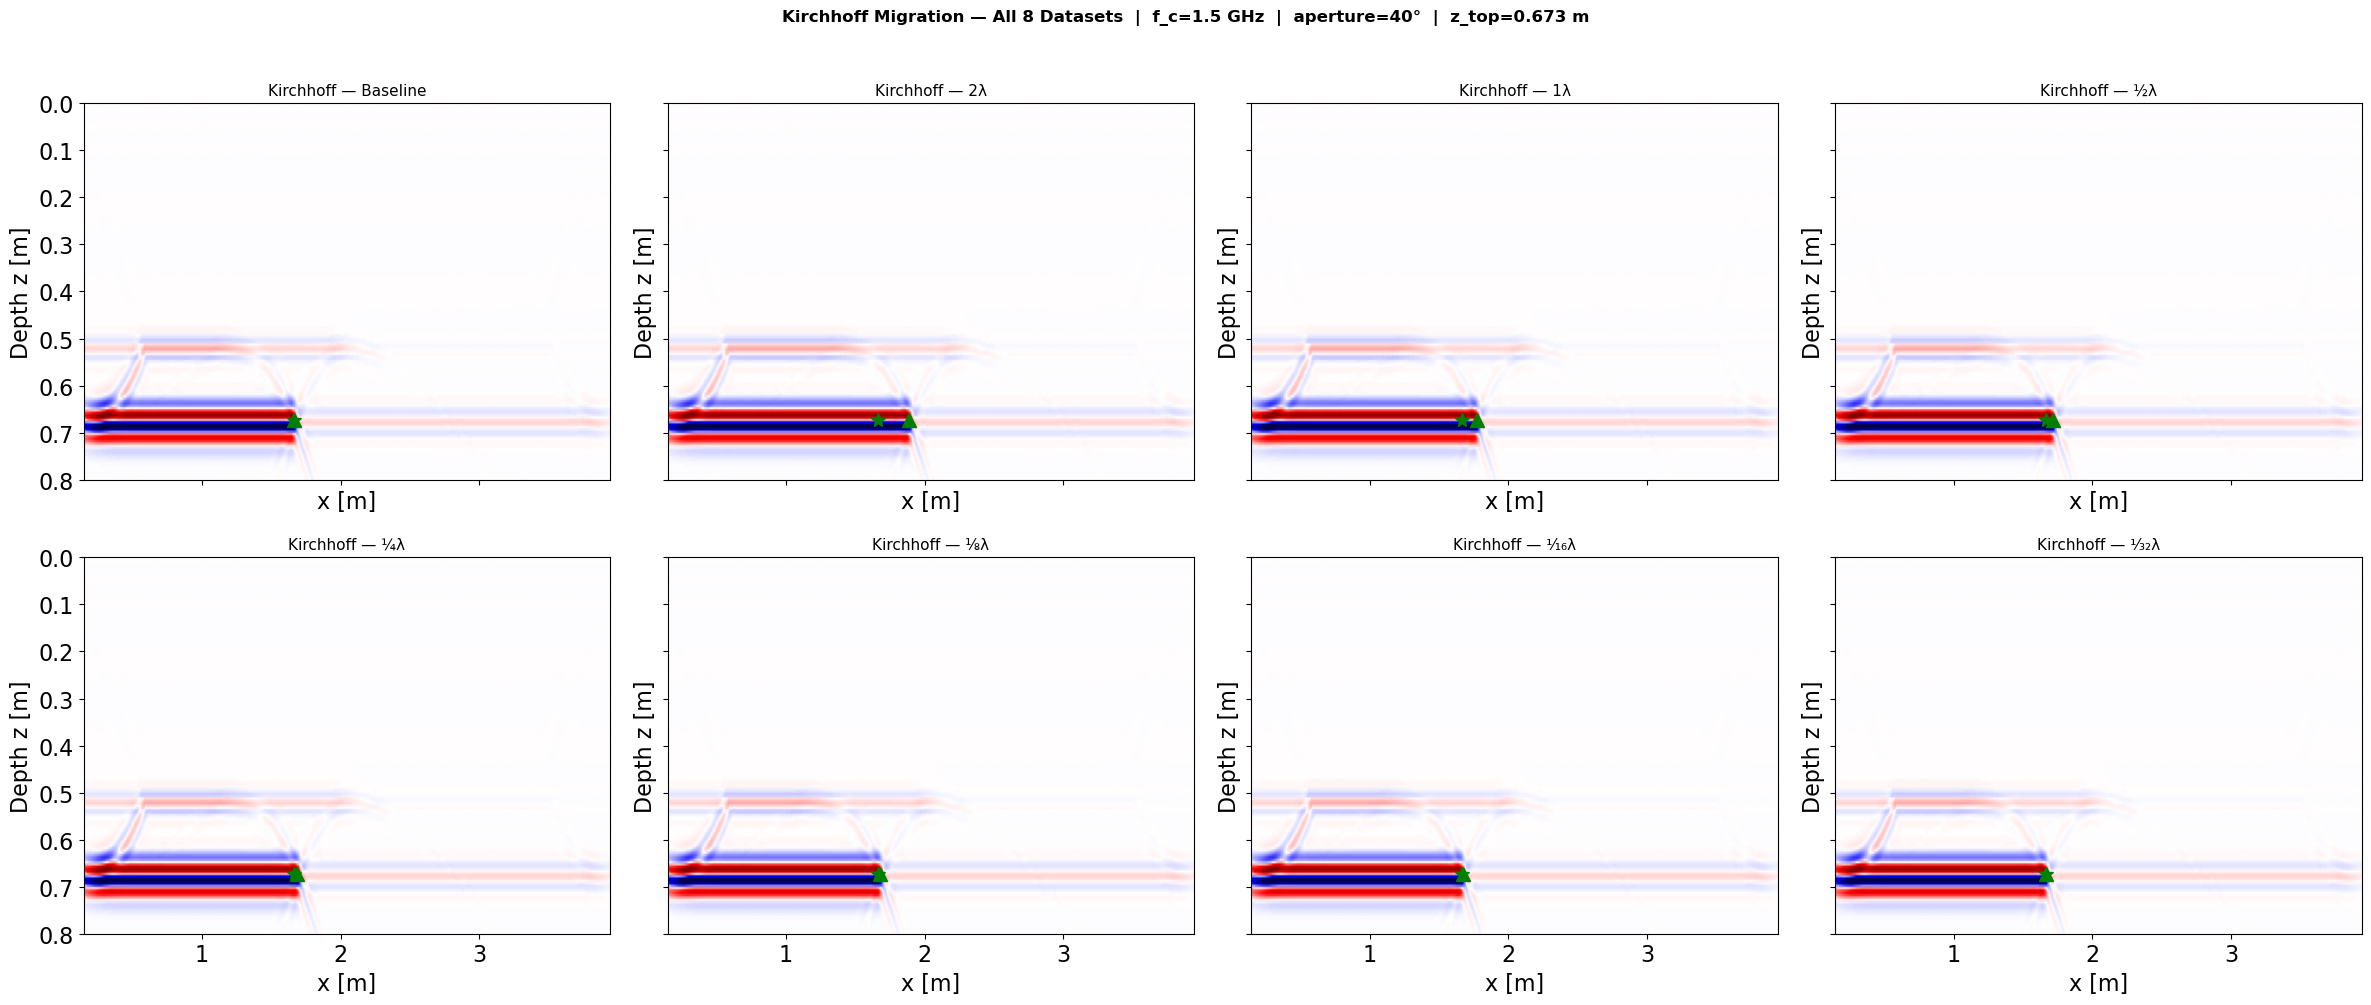

  [saved] FF_006_Kirchhoff_Migration_zoomed____f_c15_GHz____aperture40.png


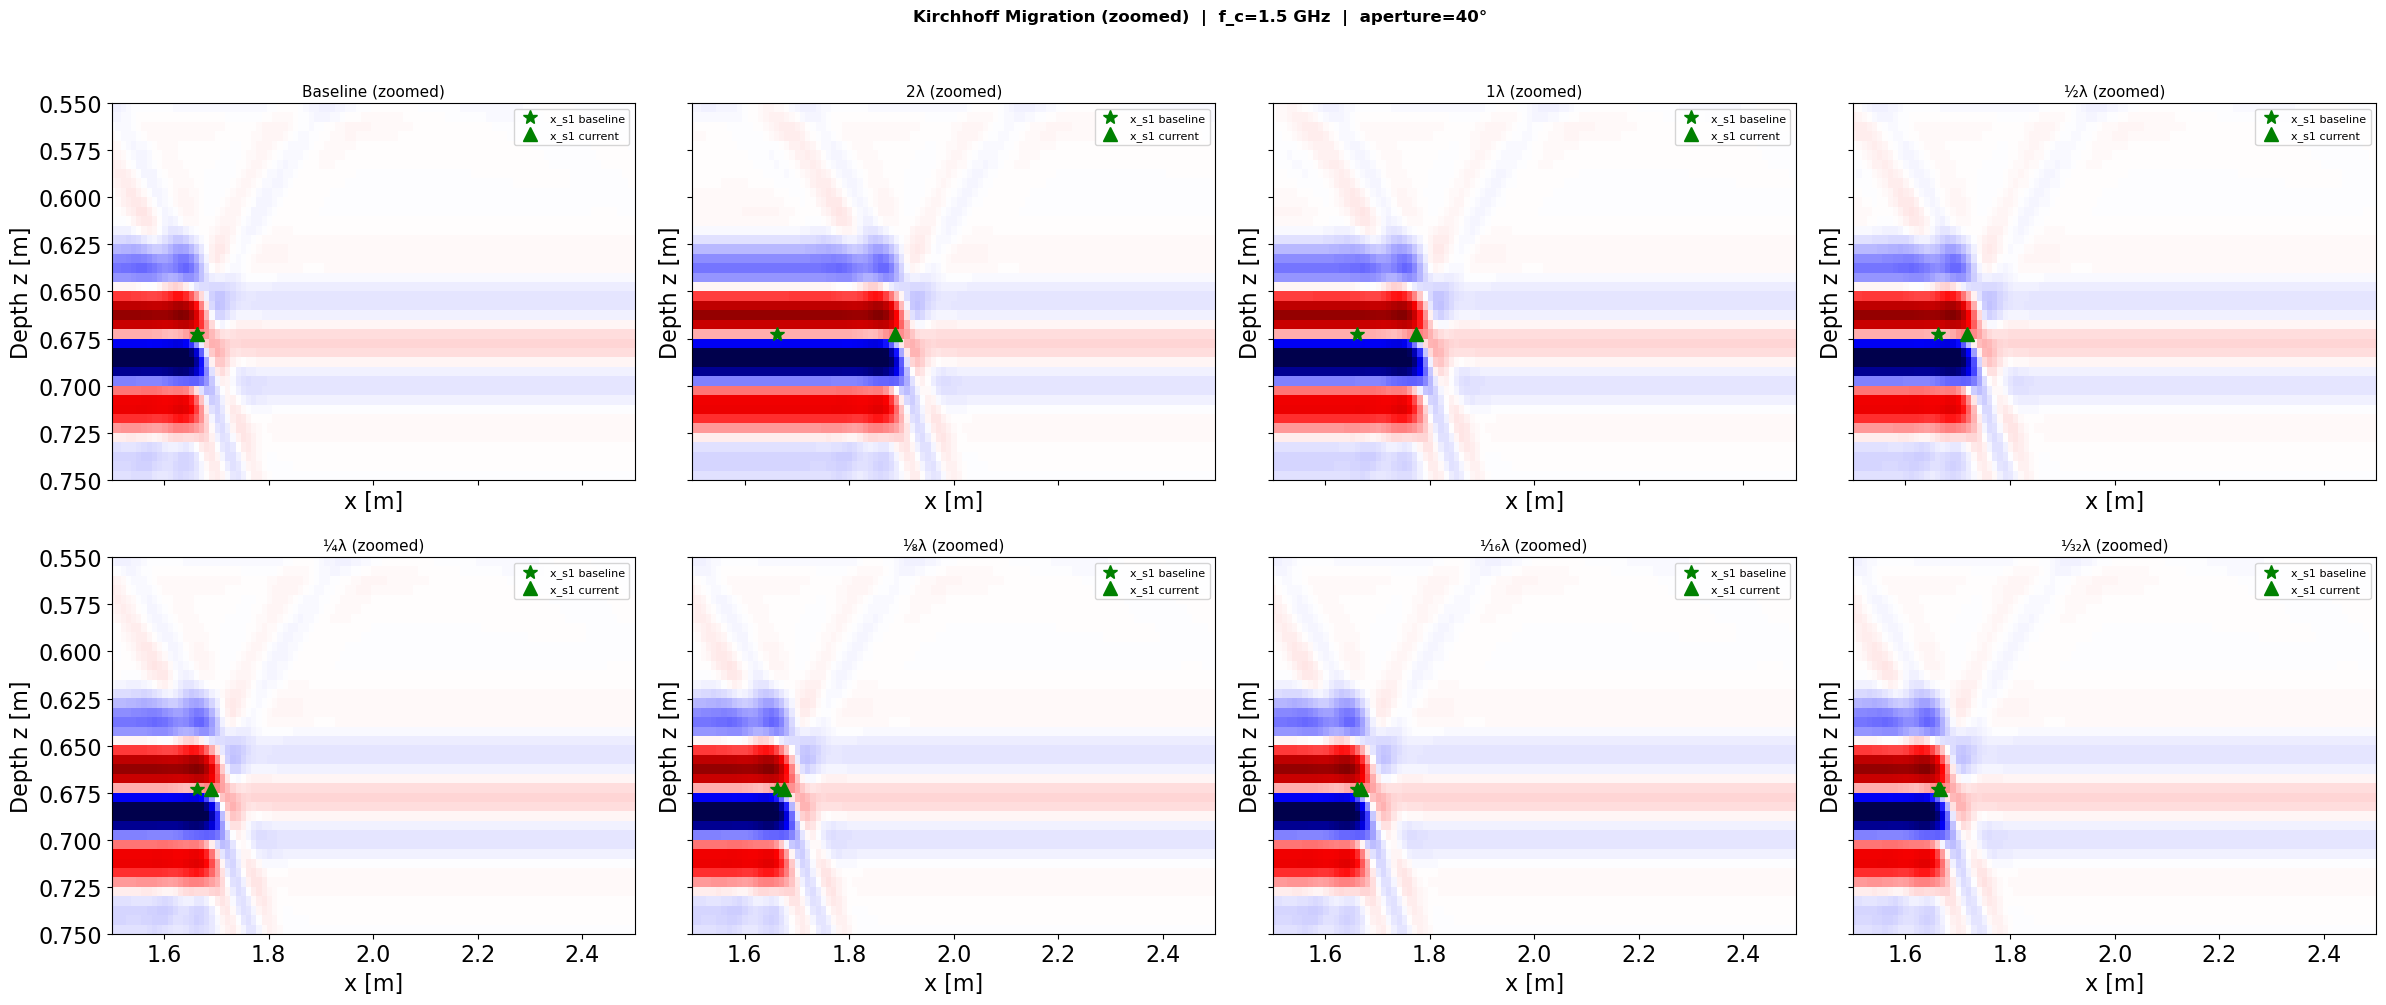

In [11]:
# ── Plot: full extent ──────────────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0], z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i], z_top, 'g^', ms=10, zorder=5, label='x_s1 current')
    ax.set_title(f'Kirchhoff — {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Kirchhoff Migration — All 8 Datasets  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°  |  z_top={z_top:.3f} m',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0], z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i], z_top, 'g^', ms=10, zorder=5, label='x_s1 current')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Kirchhoff Migration (zoomed)  |  f_c={f_c_GHz} GHz  |  aperture={ANGLE_AP}°',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


  [saved] FF_007_Kirchhoff_Migration__TimeLapse_Differences_migrated__migrate.png


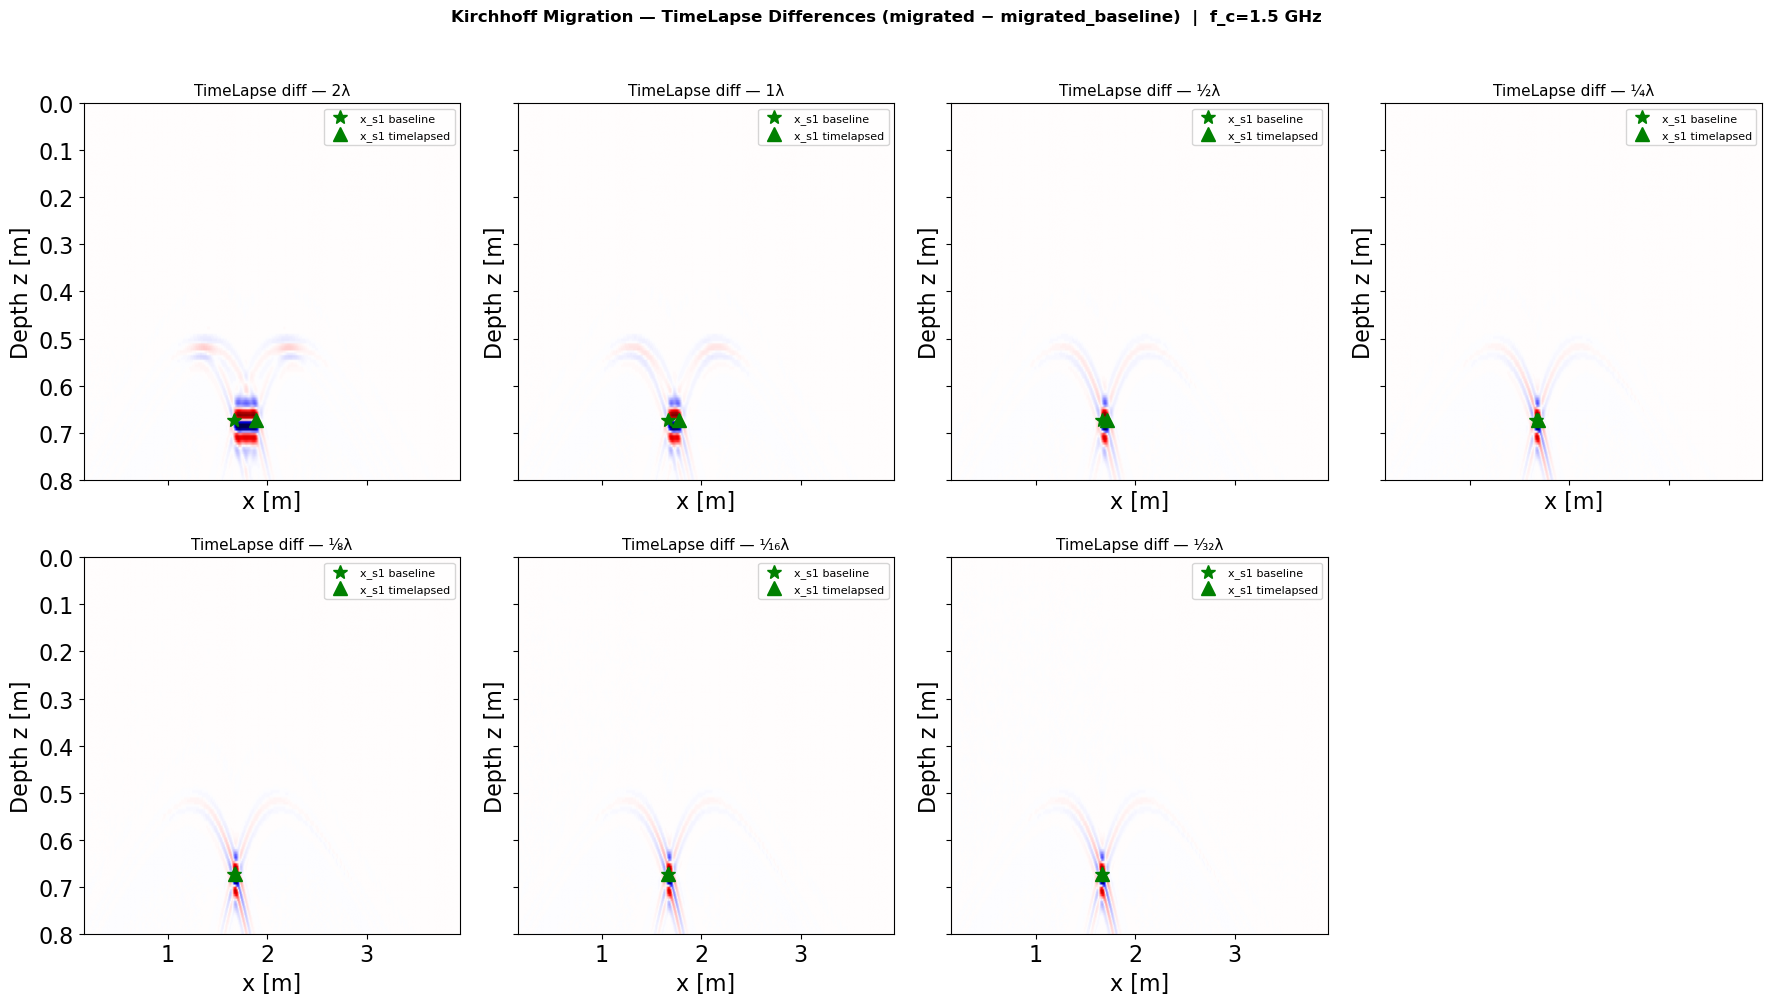

  [saved] FF_008_Kirchhoff_Migration__TimeLapse_Differences_zoomed.png


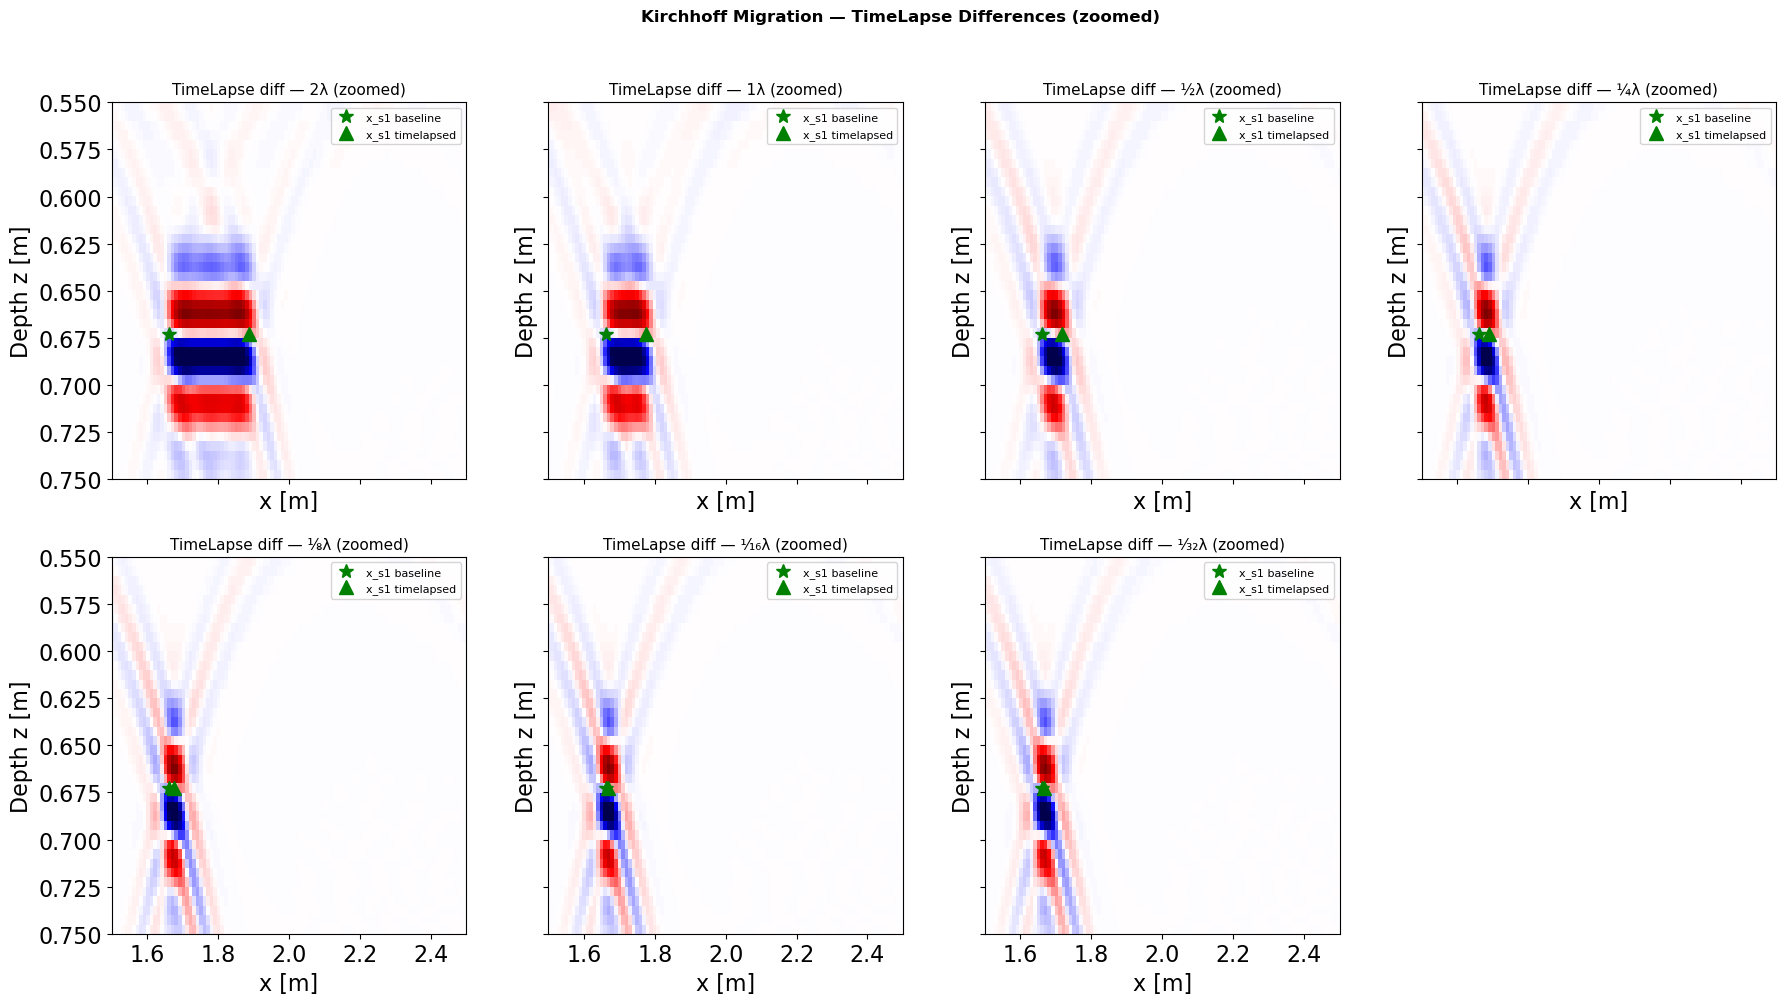

In [12]:
# ── Kirchhoff timelapse differences (migrated − migrated_baseline) ─────────────
migrated_diff = {label: migrated[label] - migrated['Baseline'] for label in labels}

fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_title(f'TimeLapse diff — {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Kirchhoff Migration — TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_timelapse_diff.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Zoomed ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'TimeLapse diff — {label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Kirchhoff Migration — TimeLapse Differences (zoomed)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'kirchhoff_timelapse_diff_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


# Gazdag Phase-Shift Migration

f-k domain migration via **PyLops `PhaseShift`** downward continuation.  
Uses the same preprocessed (tapered + t0-shifted) B-scans as Kirchhoff, but operates in the
frequency-wavenumber domain: each depth step phase-shifts the wavefield by `kz·dz`.

Key implementation details:
- `v_mig = v_ice / 2` (exploding-reflector half-velocity) used internally
- 100 % spatial zero-padding each side to avoid wrap-around in kx
- Evanescent bins (`|kx| > |f|/v_mig`) are zeroed **before** the depth loop to prevent smile artefacts accumulating at the t = 0 imaging condition
- Green stars mark the true cylinder-top positions

_____________
Add padding in space and time up to the next power of 2
_____________

In [13]:
import pylops

## Run Migration on All Datasets

In [14]:
# ── Gazdag phase-shift migration on all 8 datasets ────────────────────────────────
migrated_gz = {}

for label, raw in zip(labels_all, outputs_static):
    _, shifted = preprocess(raw, dt_ns, t0_ns, time_ns)   # (n_tr, n_t), t0-shifted
    print(f'[{label}] Running Gazdag ...', flush=True)
    t0 = _time.perf_counter()
    img = gazdag_migration(
        shifted.T,       # (n_t, n_tr) — time first
        x_traces, time_ns, z_img, v_ice
    )
    print(f'  Done in {_time.perf_counter()-t0:.1f} s  shape={img.shape}')
    migrated_gz[label] = img


[Baseline] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 203.8 s  shape=(160, 380)
[2λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 202.2 s  shape=(160, 380)
[1λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 210.5 s  shape=(160, 380)
[½λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 215.9 s  shape=(160, 380)
[¼λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 237.3 s  shape=(160, 380)
[⅛λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 240.8 s  shape=(160, 380)
[¹⁄₁₆λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725/4834740 (1.0%)
  Done in 243.9 s  shape=(160, 380)
[¹⁄₃₂λ] Running Gazdag ...
  nx=380 → nx_pad=1140,  evanescent bins zeroed: 48725

  [saved] FF_009_Gazdag_Phase-Shift_Migration__All_7_Datasets____f_c15_GHz.png


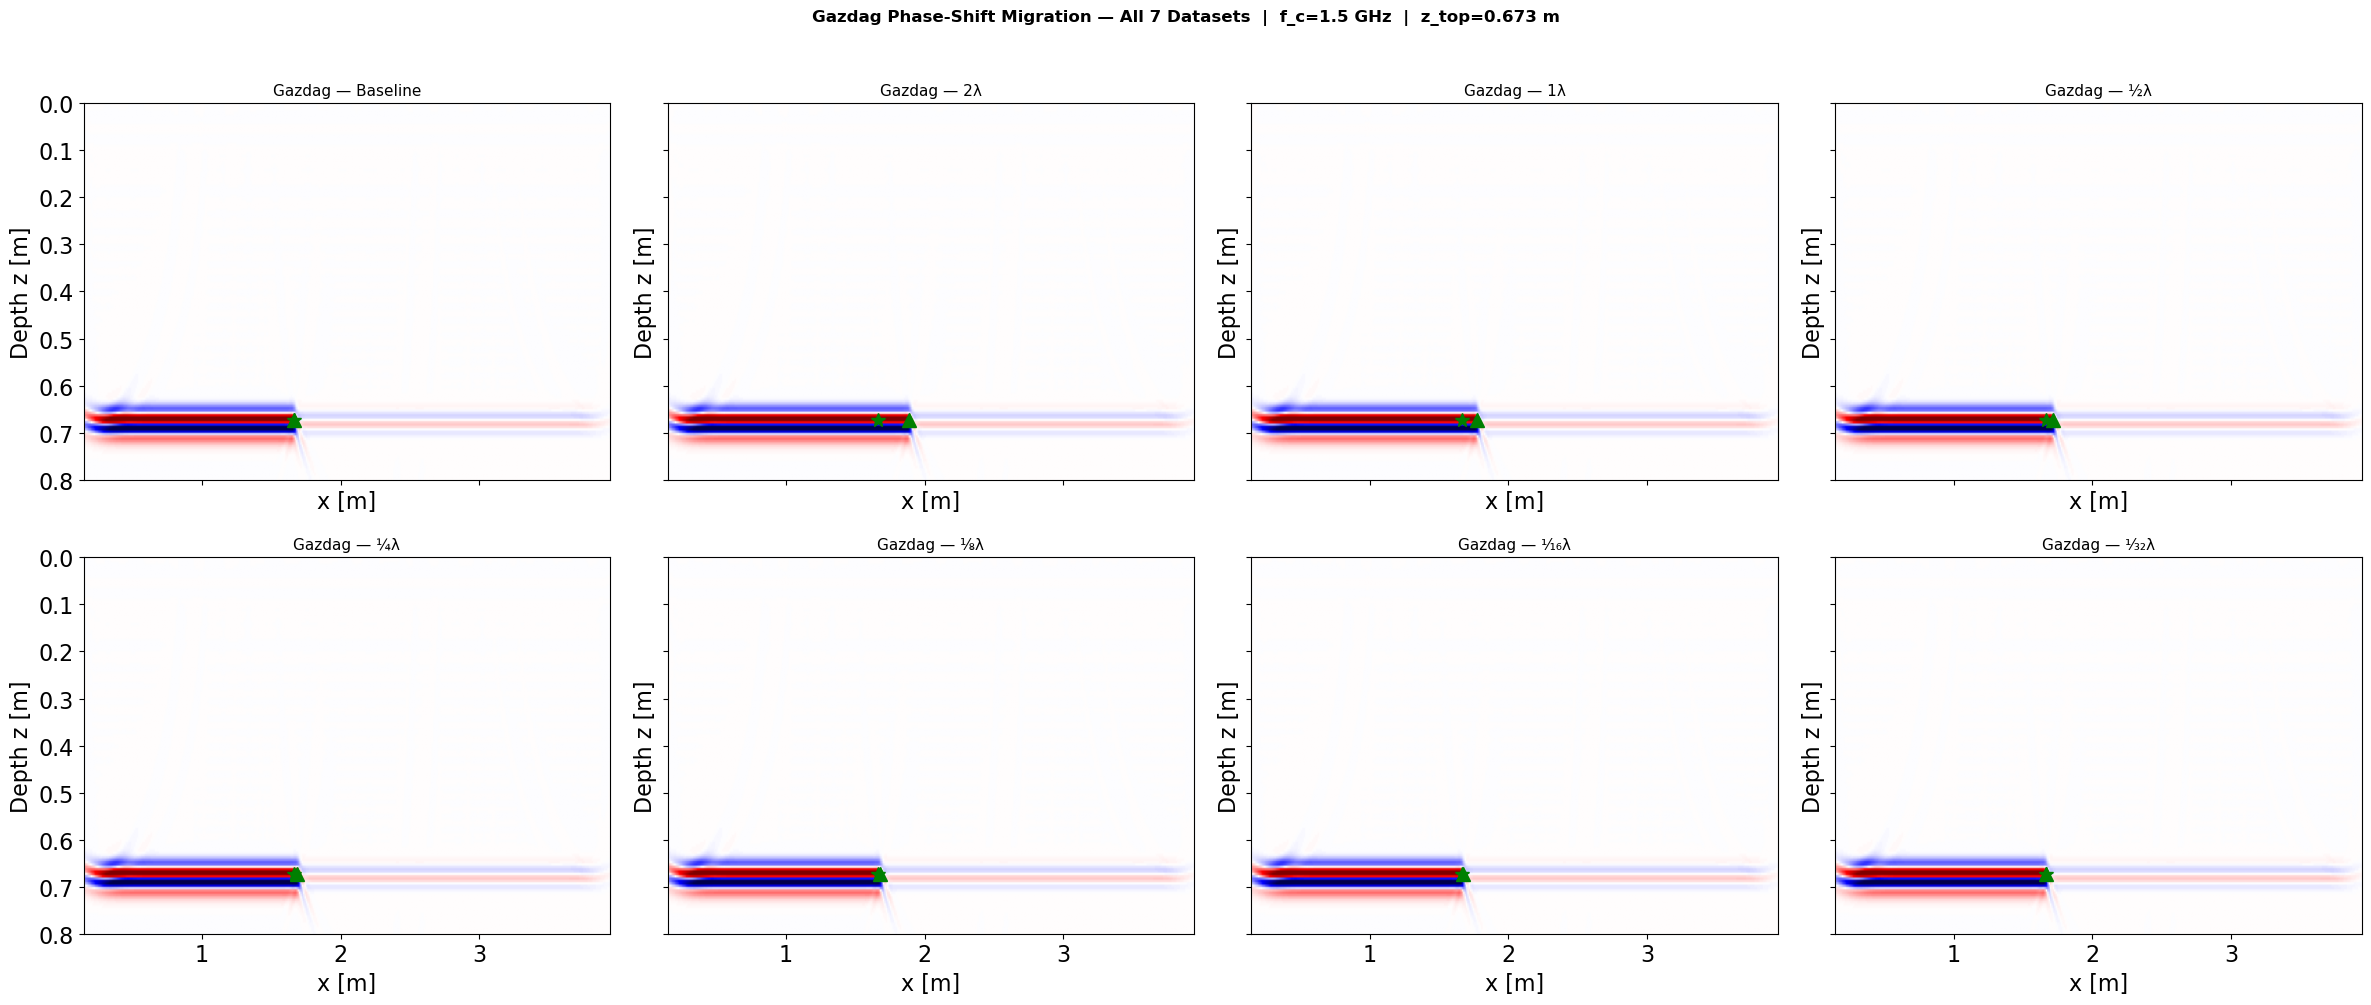

  [saved] FF_010_Gazdag_Phase-Shift_Migration_zoomed____f_c15_GHz.png


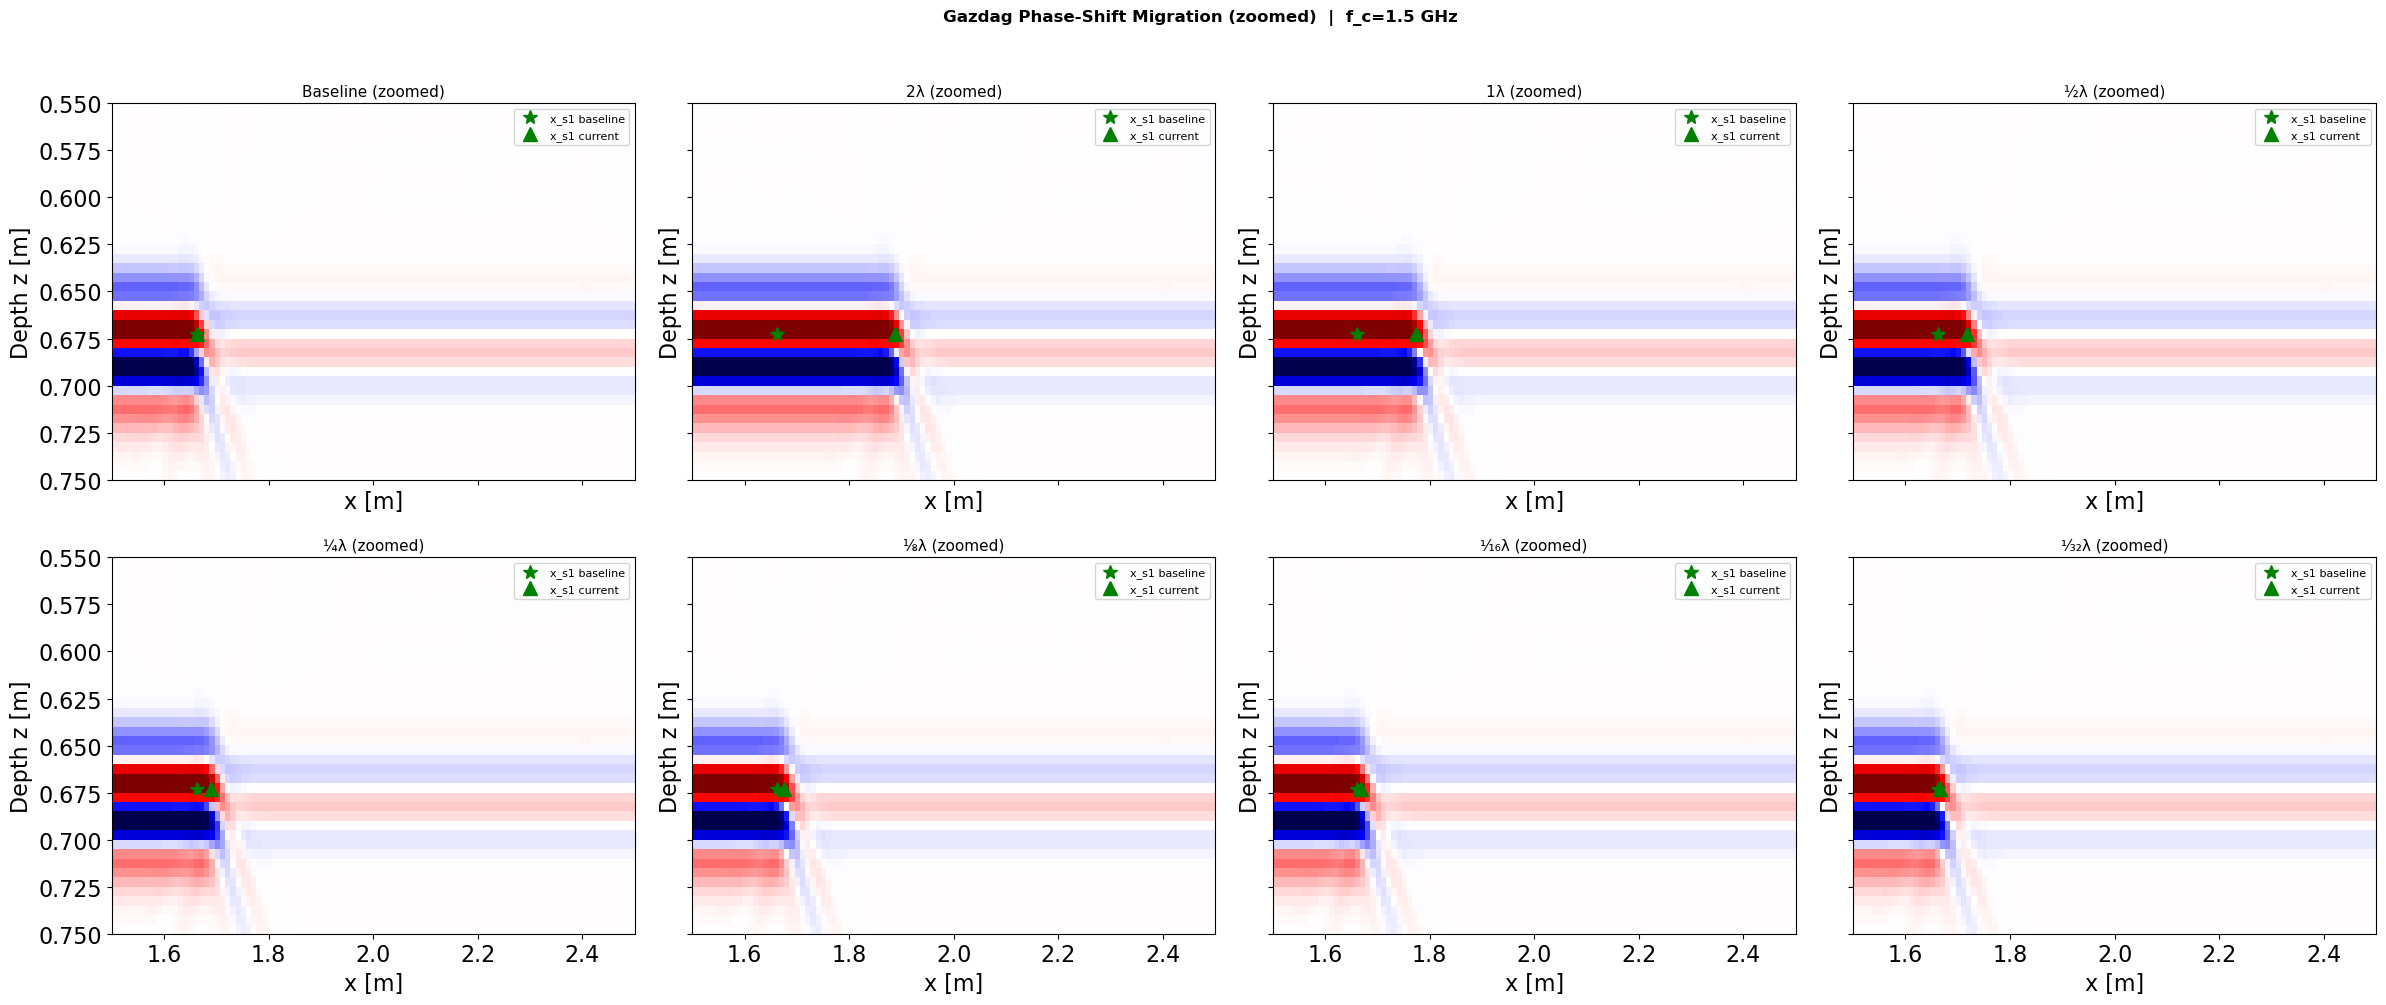

In [15]:
# ── Plot: full extent ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
# axes.ravel()[-1].set_visible(False)   # 7 items in 2×4 grid — hide last slot
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated_gz.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0], z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i], z_top, 'g^', ms=10, zorder=5, label='x_s1 current')
    ax.set_title(f'Gazdag — {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')

plt.suptitle(
    f'Gazdag Phase-Shift Migration — All 7 Datasets  |  f_c={f_c_GHz} GHz  |  z_top={z_top:.3f} m',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_all_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Plot: zoomed on scatterer region ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
# axes.ravel()[-1].set_visible(False)
for i, (ax, (label, img)) in enumerate(zip(axes.ravel(), migrated_gz.items())):
    vmax = np.max(np.abs(img)) * 0.8
    ax.imshow(img, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0], z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i], z_top, 'g^', ms=10, zorder=5, label='x_s1 current')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Phase-Shift Migration (zoomed)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_all_datasets_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


  [saved] FF_011_Gazdag_Migration__TimeLapse_Differences_migrated__migrated_b.png


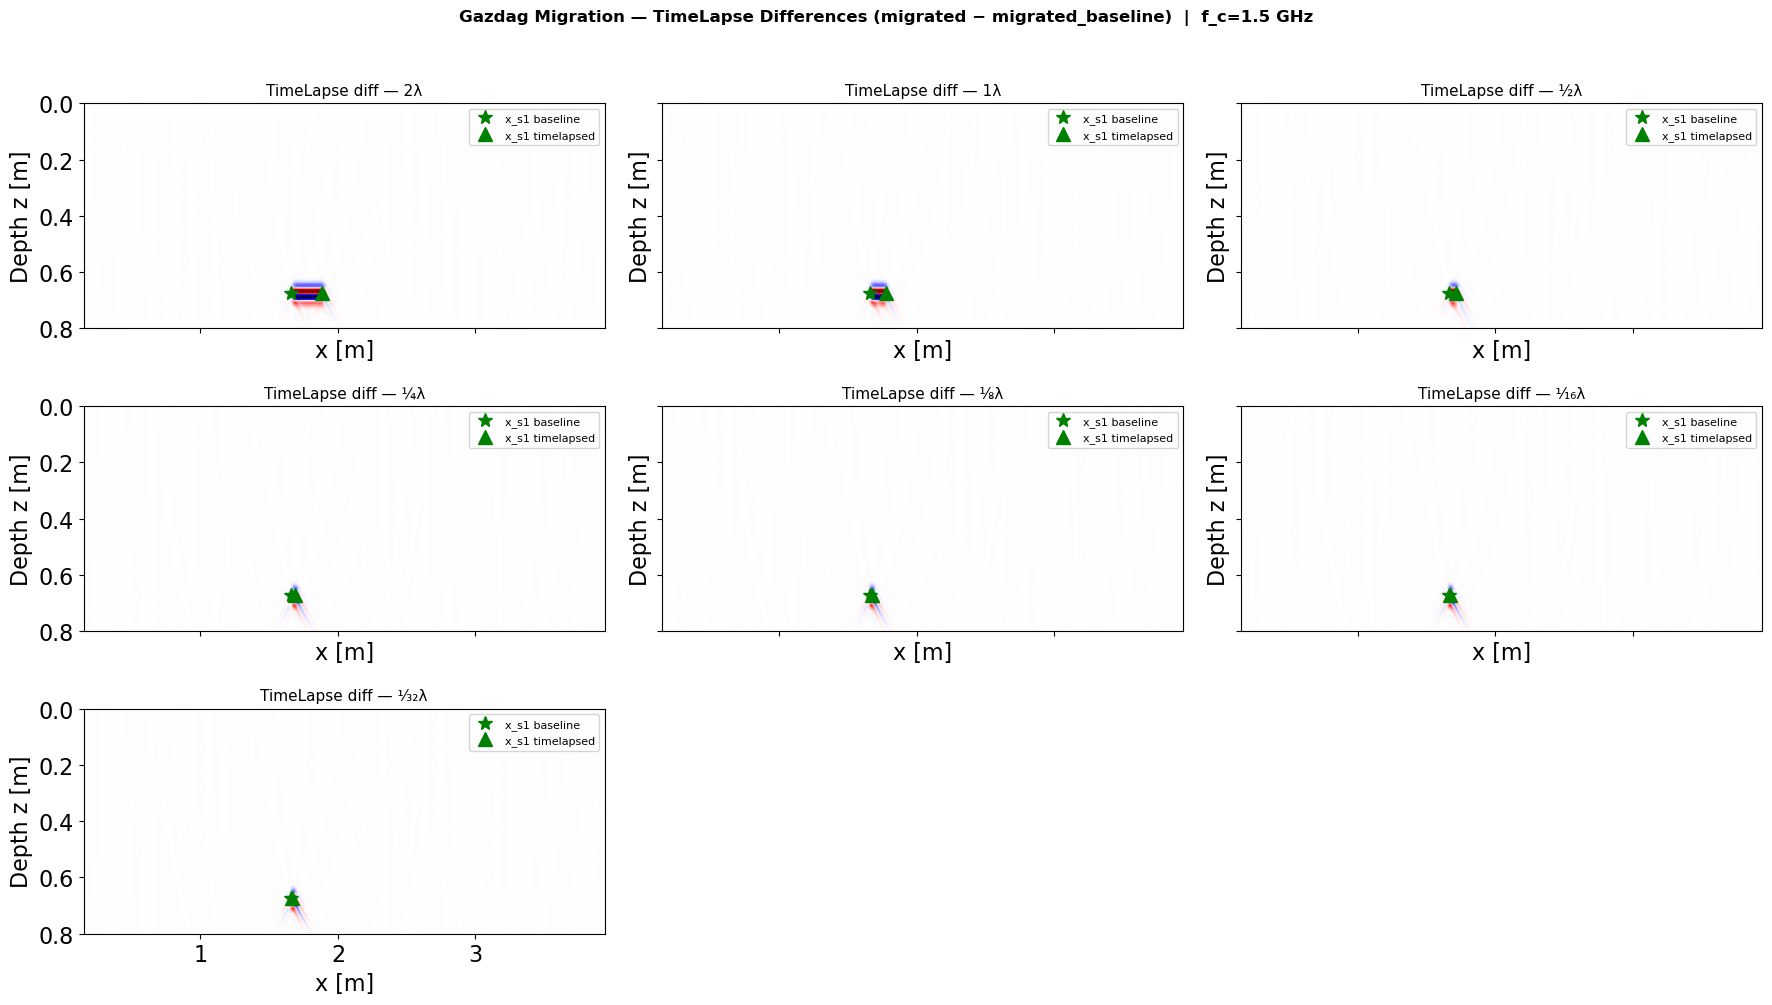

  [saved] FF_012_Gazdag_Migration__TimeLapse_Differences_zoomed.png


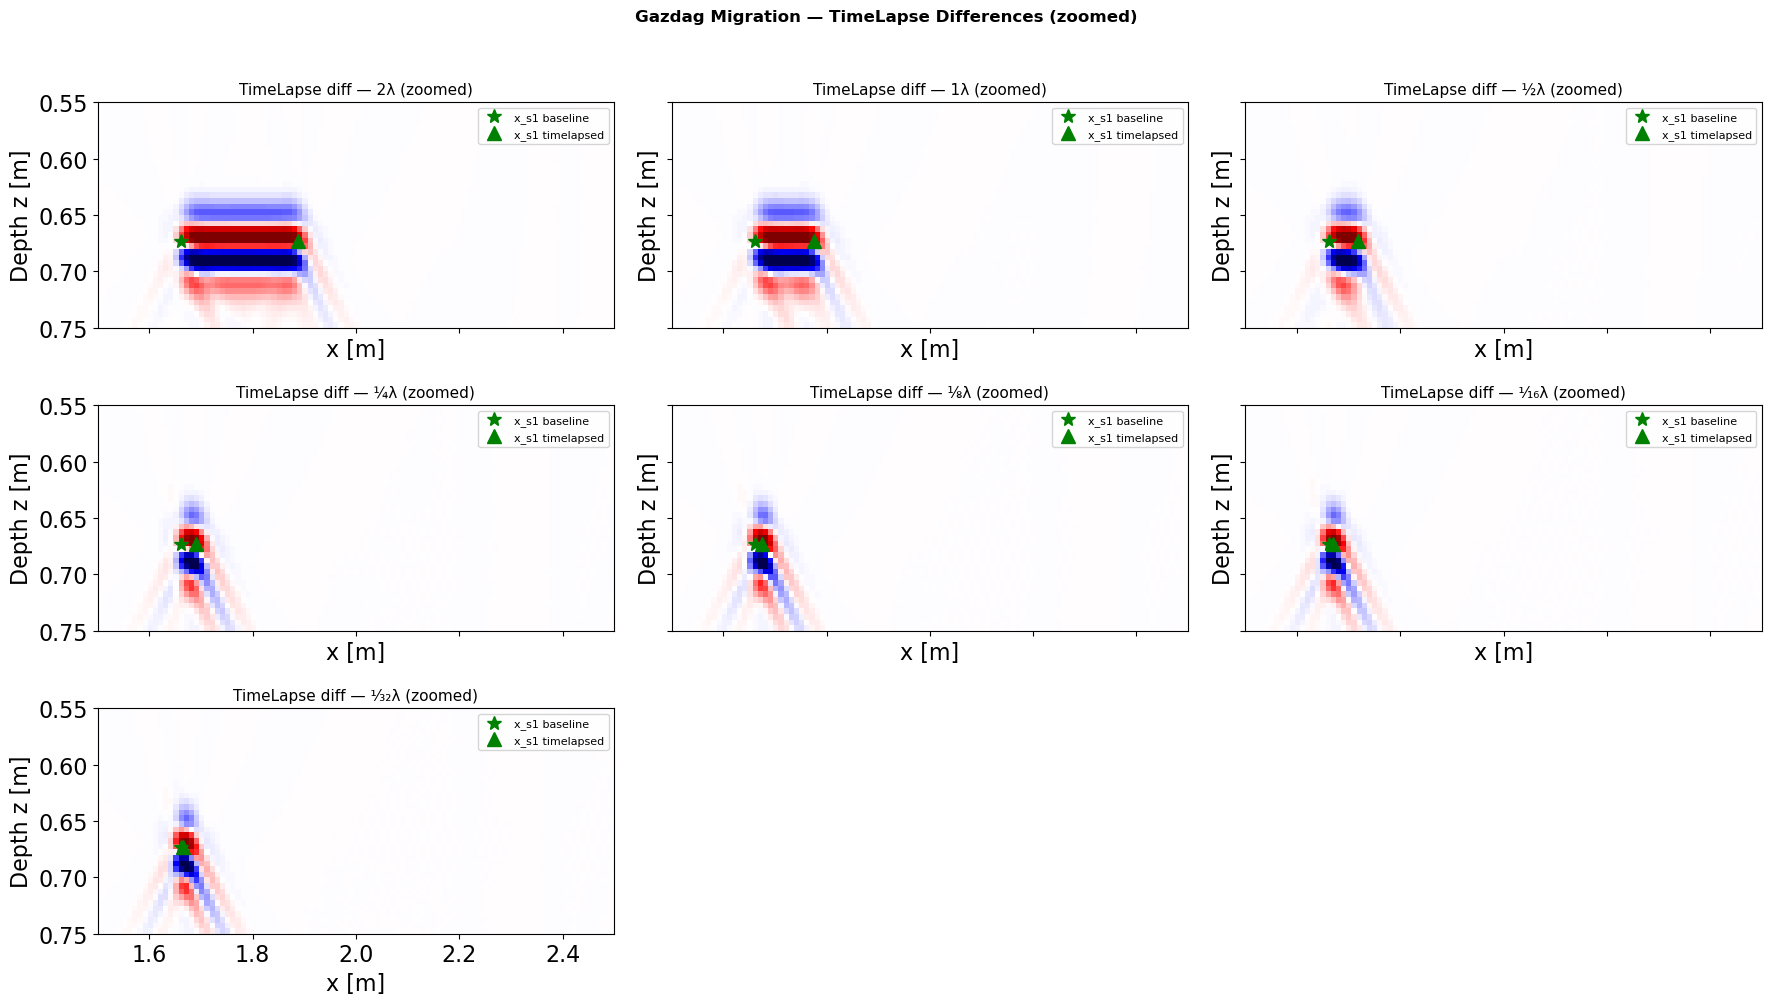

In [16]:
# ── Gazdag timelapse differences (migrated − migrated_baseline) ──────────────────────
migrated_gz_diff = {label: migrated_gz[label] - migrated_gz['Baseline'] for label in labels}

fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True, sharey=True)
axes.ravel()[-2].set_visible(False)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_gz_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_title(f'TimeLapse diff — {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Migration — TimeLapse Differences (migrated − migrated_baseline)  |  f_c={f_c_GHz} GHz',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_timelapse_diff.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Zoomed ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 10), sharex=True, sharey=True)
axes.ravel()[-2].set_visible(False)
axes.ravel()[-1].set_visible(False)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), migrated_gz_diff.items())):
    vmax = np.max(np.abs(diff)) * 0.8
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_mig, origin='upper')
    ax.plot(x_scatterer_1[0],     z_top, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], z_top, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_xlim(1.5, 2.5); ax.set_ylim(0.75, 0.55)
    ax.set_title(f'TimeLapse diff — {label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('Depth z [m]')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    f'Gazdag Migration — TimeLapse Differences (zoomed)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'gazdag_timelapse_diff_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


# LSM

# Back-Propagation Migration

Time-reversal migration: re-inject the time-reversed, normalised B-scan traces at the
original receiver positions through a **half-velocity medium** (eps_r × 4 so v → v_ice/2).

Under the exploding-reflector hypothesis every scatterer focuses simultaneously at

> **t_focus = T − t0_ns**

where T is the total simulation window. Snapshots are captured in a narrow window just
before t_focus so the collapsed wavefield image can be extracted.

| Parameter | Value |
|-----------|-------|
| Injection positions | Rx locations (Tx + 0.1 m offset) |
| Medium | eps_r × 4 → v = v_ice / 2 |
| Source stride | every `STRIDE`-th trace (tunes performance vs coverage) |

In [17]:
# ── Back-propagation parameters ──────────────────────────────────────────────
# Sources placed at Tx-Rx midpoints (x_traces) — consistent with exploding-
# reflector half-velocity (v_mig = v/2) used in gazdag_migration.
slugs_all = ['baseline', '2lambda', '1lambda', '0p5lambda', '0p25lambda', '0p125lambda', '0p0625lambda', '0p03125lambda']
STRIDE   = 1    # use every Nth trace — reduces gprMax source count
N_SNAP   = 30   # number of snapshots in the focus window
SNAP_WIN = 1.0  # [ns] window before focus time to capture

# ── Generate files for all 8 datasets ────────────────────────────────────────
print(f'Back-propagation file generation  (stride={STRIDE}, {N_SNAP} snapshots)\n')
bp_paths = {}
for label, slug, raw in zip(labels_all, slugs_all, outputs_static):
    tapered, _ = preprocess(raw, dt_ns, t0_ns, time_ns)
    in_path, n_src, n_snaps, t_focus = write_backprop_files(
        STUDY_ROOT, label, slug, tapered, dt_ns, x_traces,
        t0_ns, eps_r_ice, v_ice, stride=STRIDE, n_snap=N_SNAP, snap_win=SNAP_WIN
    )
    bp_paths[label] = in_path
    exc_mb = (in_path.parent / 'excitation.txt').stat().st_size / 1e6
    print(f'  [{label}]  {n_src} sources  |  {n_snaps} snapshots  |  '
          f'focus={t_focus:.2f} ns  |  excitation={exc_mb:.1f} MB')
    print(f'           {in_path}')

Back-propagation file generation  (stride=1, 30 snapshots)

  [Baseline]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=43.7 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study\backprop\baseline\backprop_baseline.in
  [2λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=43.7 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study\backprop\2lambda\backprop_2lambda.in
  [1λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=43.7 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study\backprop\1lambda\backprop_1lambda.in
  [½λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=43.7 MB
           C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study\backprop\0p5lambda\backprop_0p5lambda.in
  [¼λ]  380 sources  |  29 snapshots  |  focus=19.06 ns  |  excitation=43.7 MB
           C:\Users\Administrator\OneDriv

[Baseline]  29 snaps  |  focus idx=15  t=19.052 ns
[2λ]  29 snaps  |  focus idx=15  t=19.052 ns
[1λ]  29 snaps  |  focus idx=15  t=19.052 ns
[½λ]  29 snaps  |  focus idx=15  t=19.052 ns
[¼λ]  29 snaps  |  focus idx=15  t=19.052 ns
[⅛λ]  29 snaps  |  focus idx=15  t=19.052 ns
[¹⁄₁₆λ]  29 snaps  |  focus idx=15  t=19.052 ns
[¹⁄₃₂λ]  29 snaps  |  focus idx=15  t=19.052 ns
  [saved] FF_013_Back-Propagation_E__All_7_Datasets____focus_at_1906_ns.png


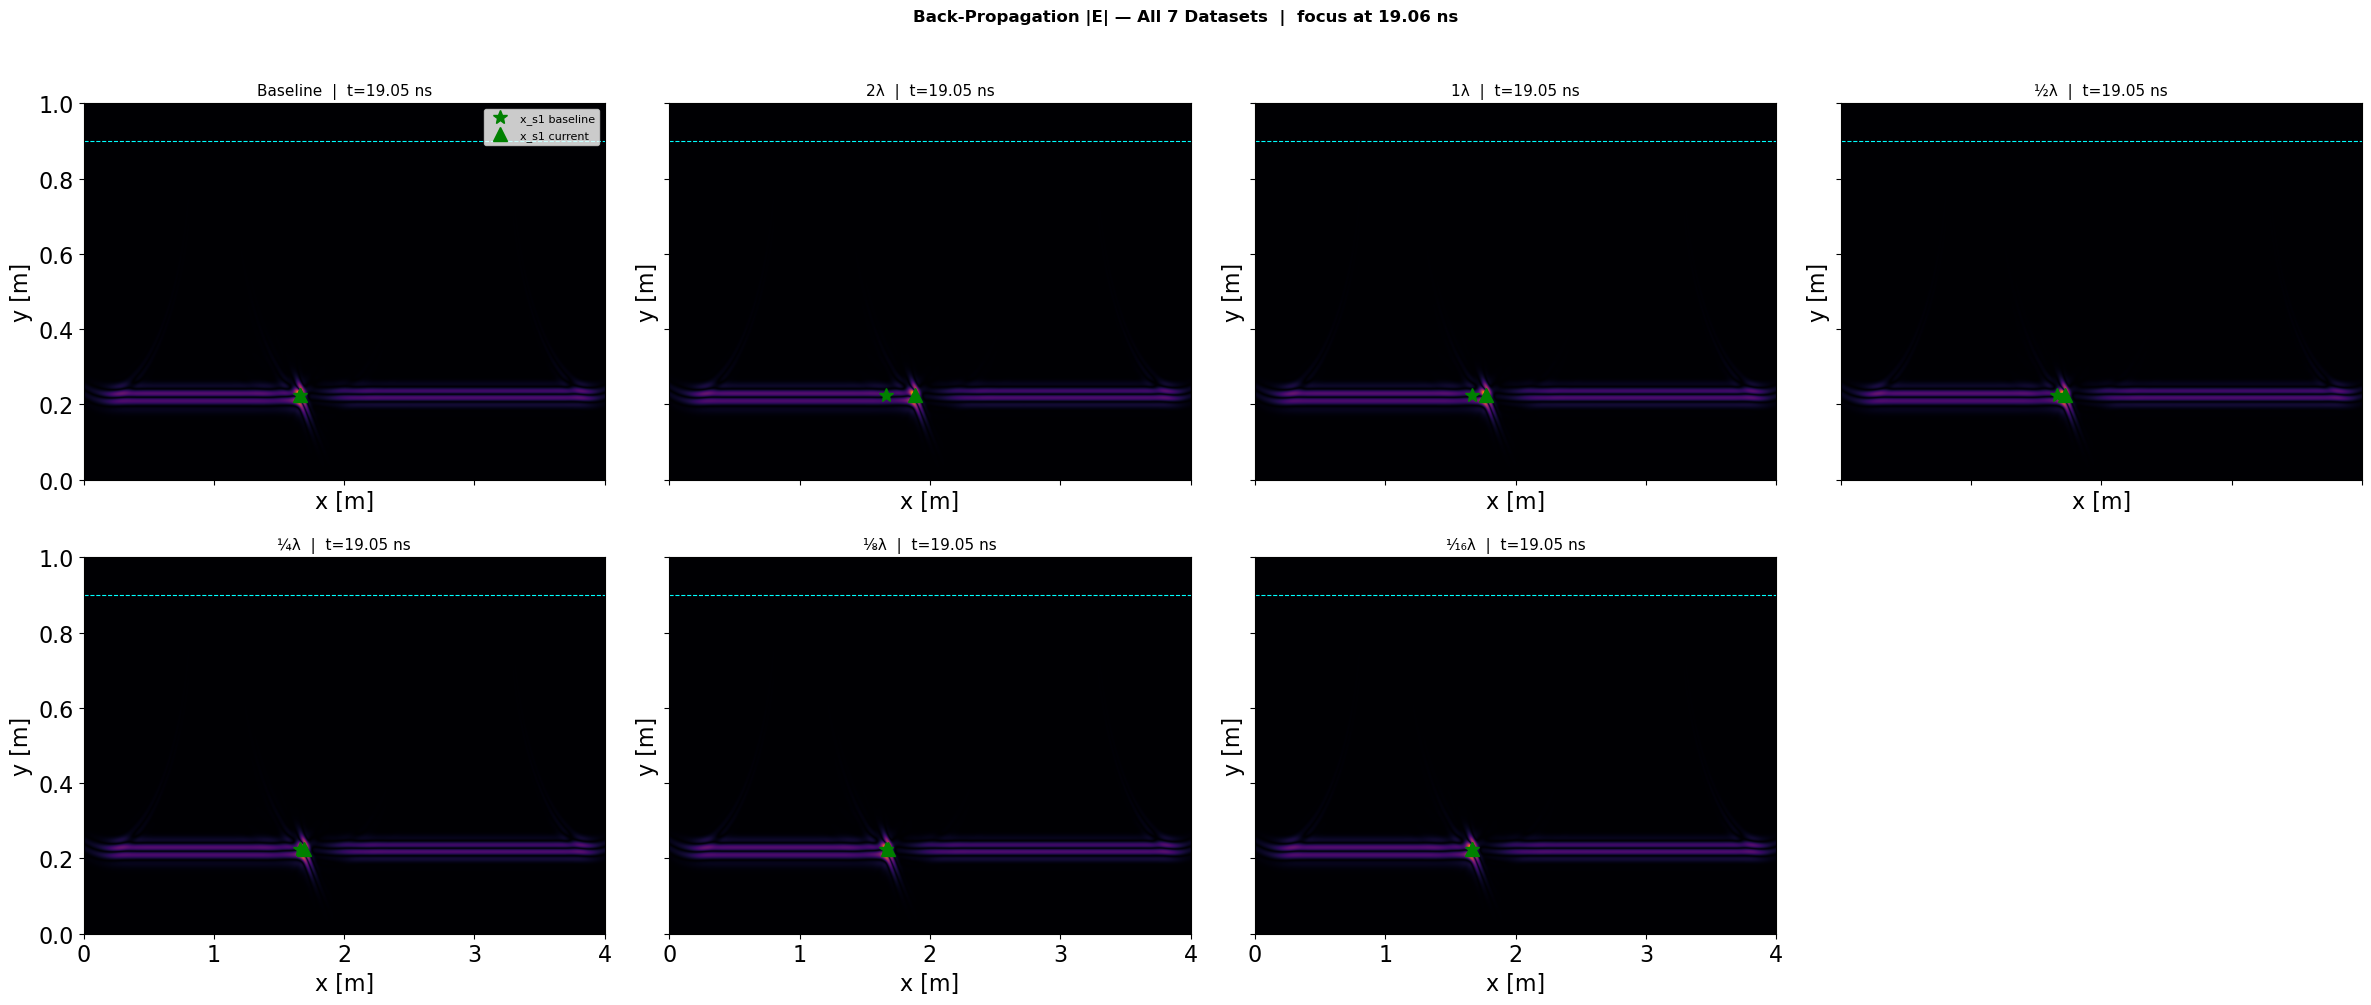

  [saved] FF_014_Back-Propagation_E_zoomed____focus_at_1906_ns.png


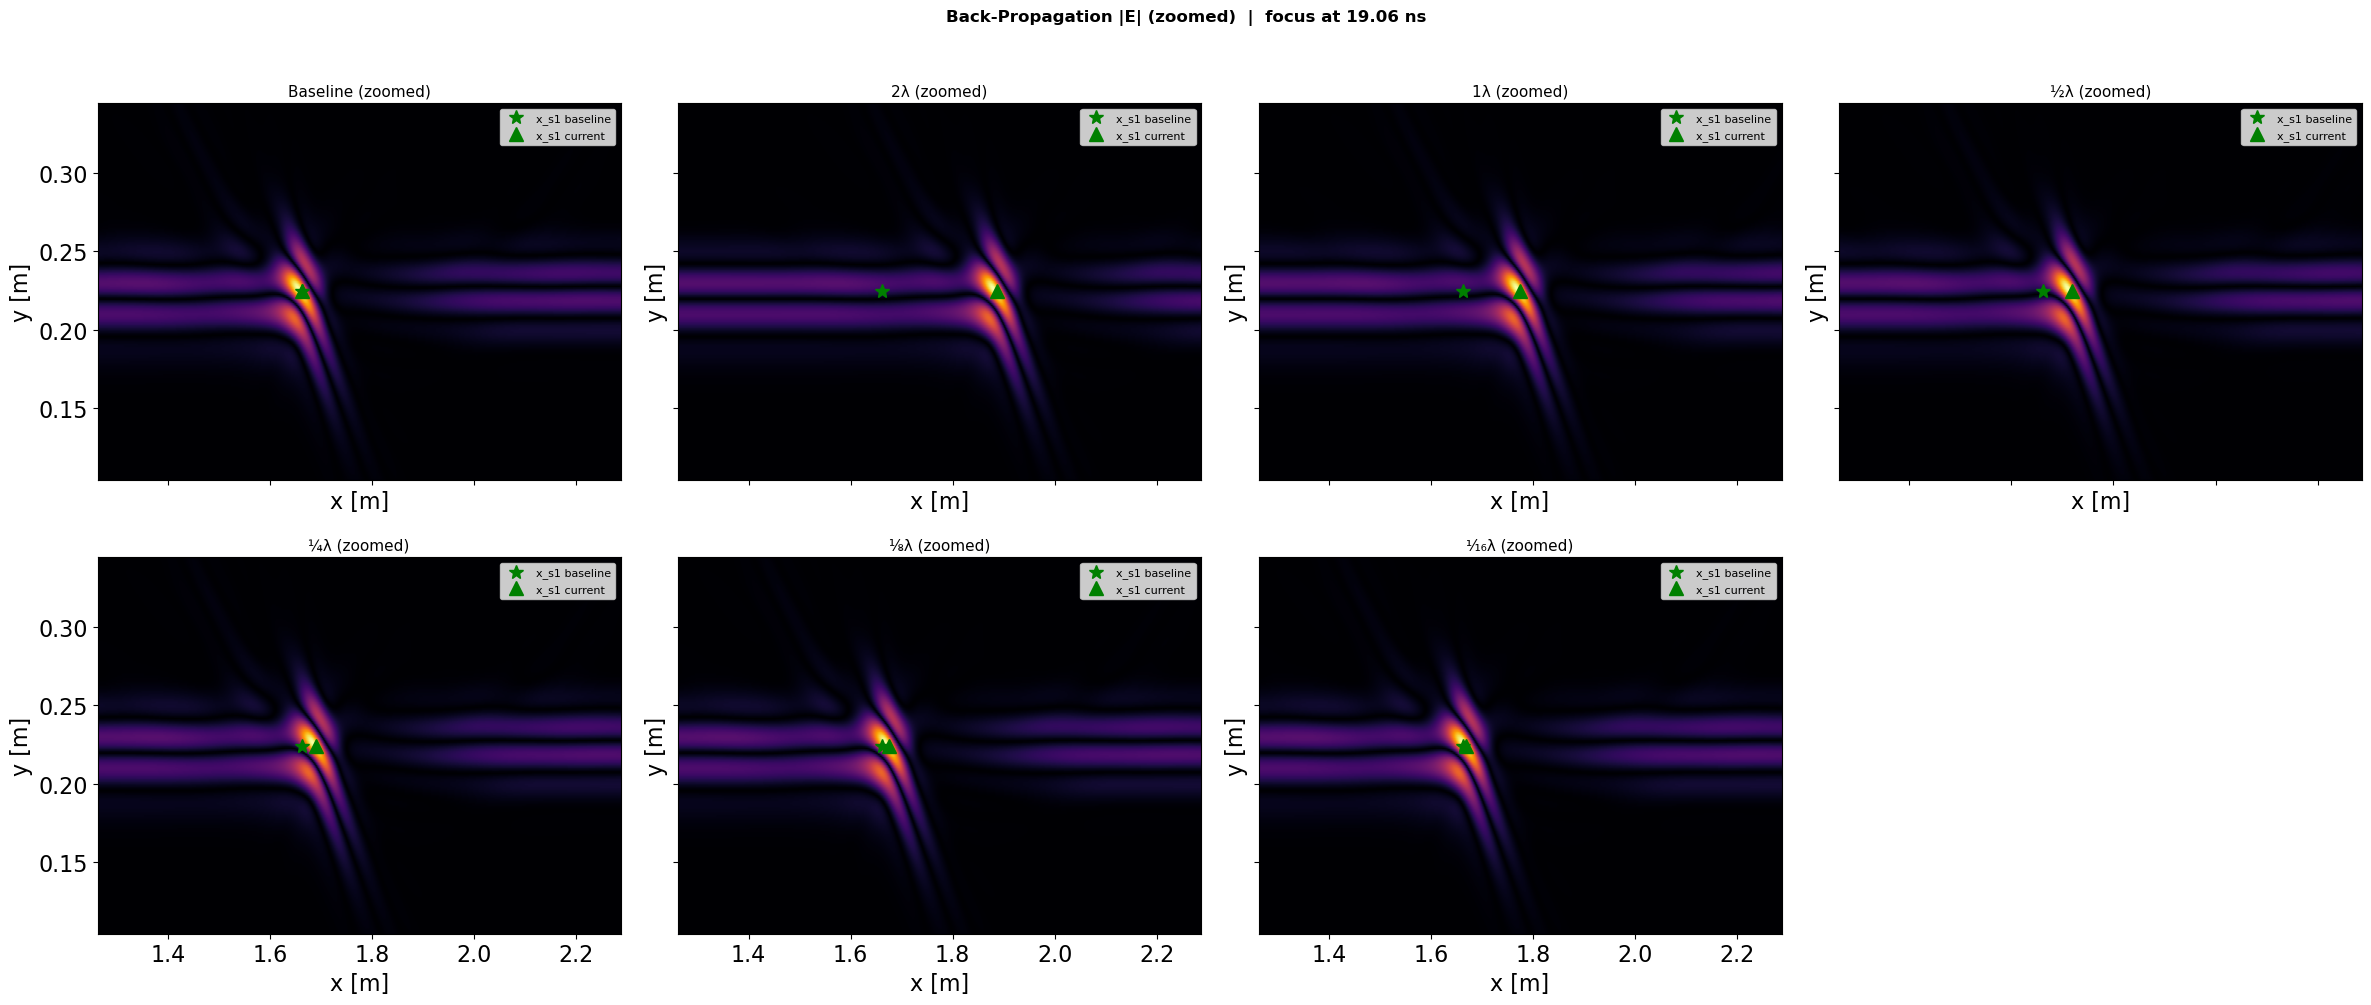

  [saved] FF_015_Back-Propagation_Ez__All_7_Datasets____focus_at_1906_ns.png


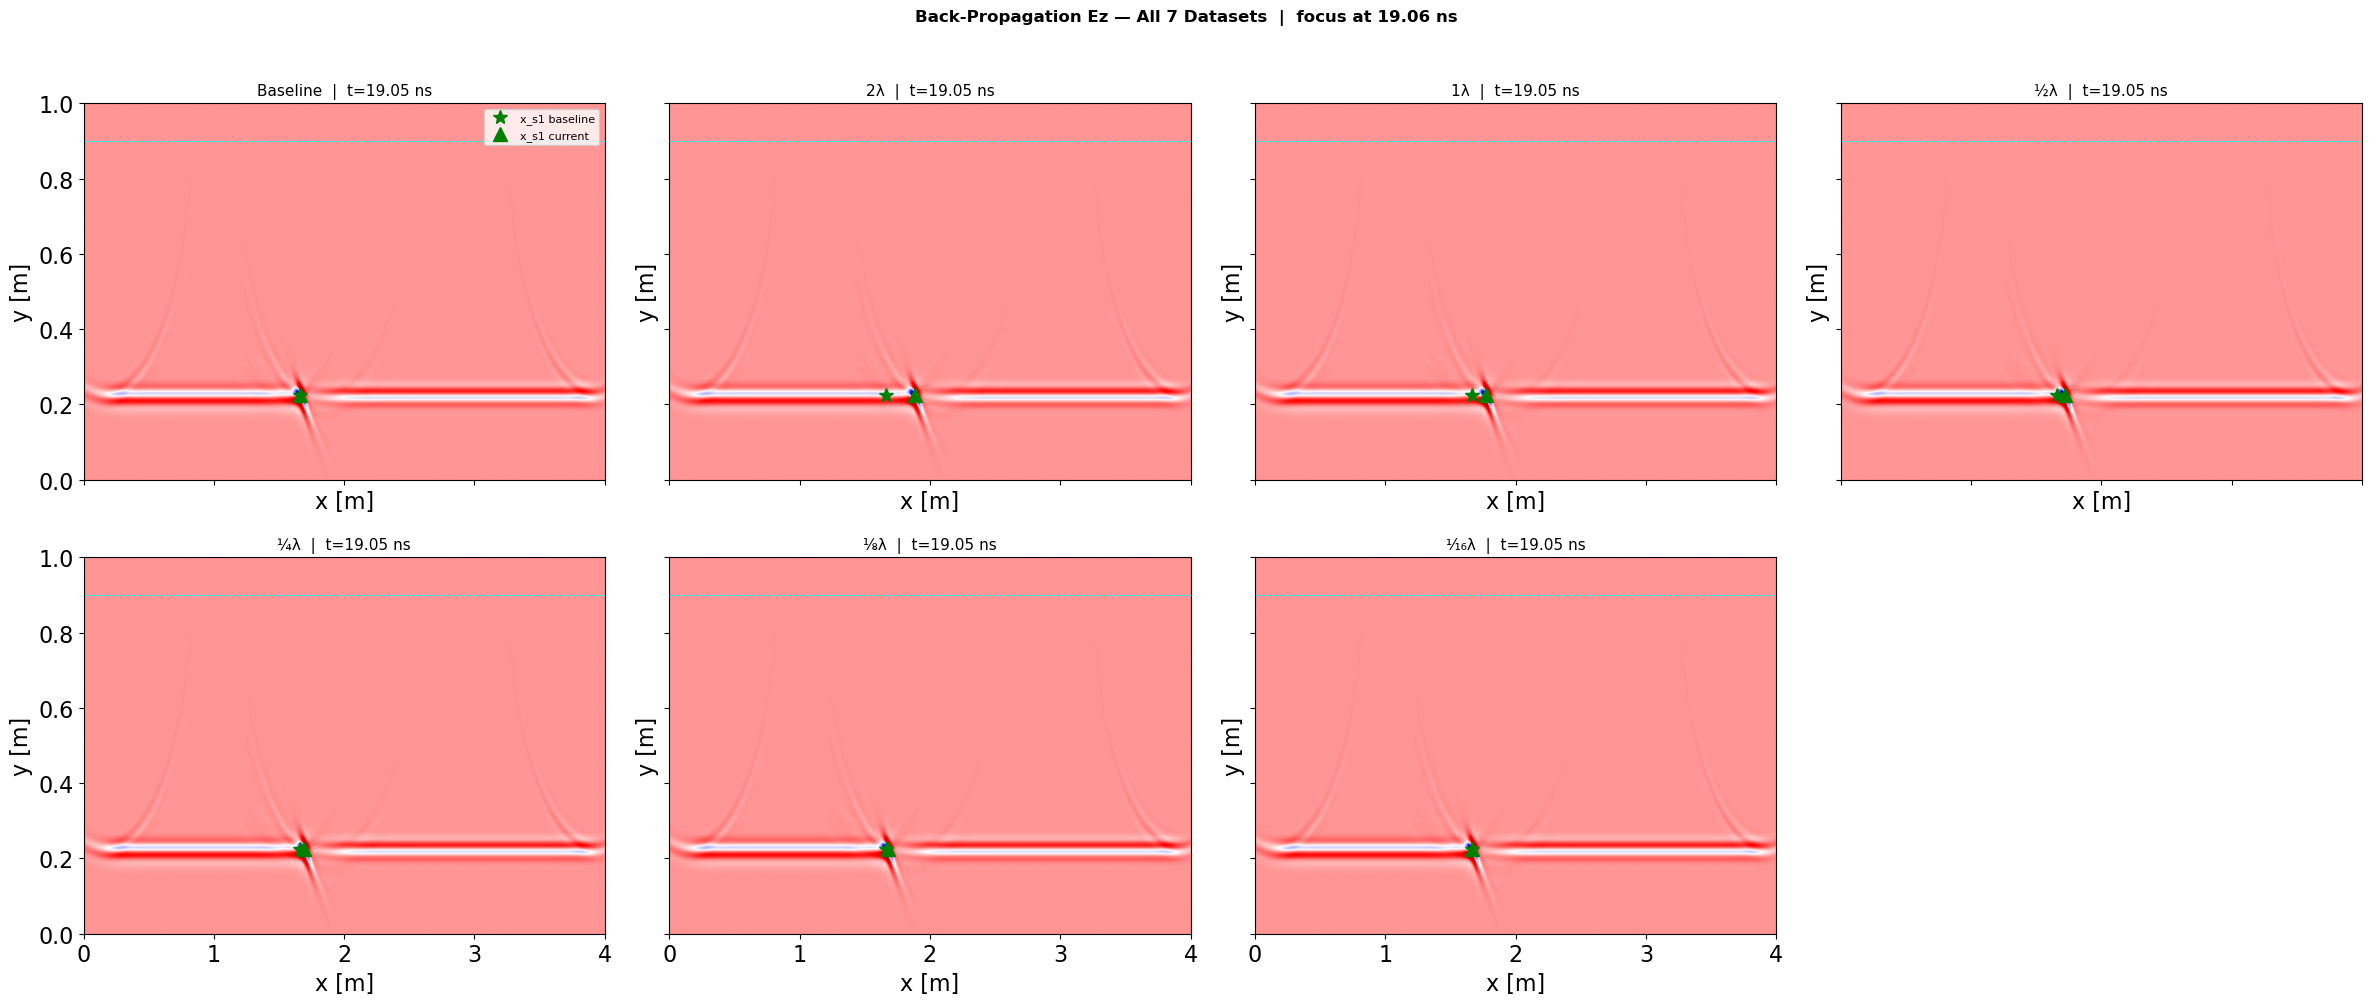

  [saved] FF_016_Back-Propagation_Ez_zoomed____focus_at_1906_ns.png


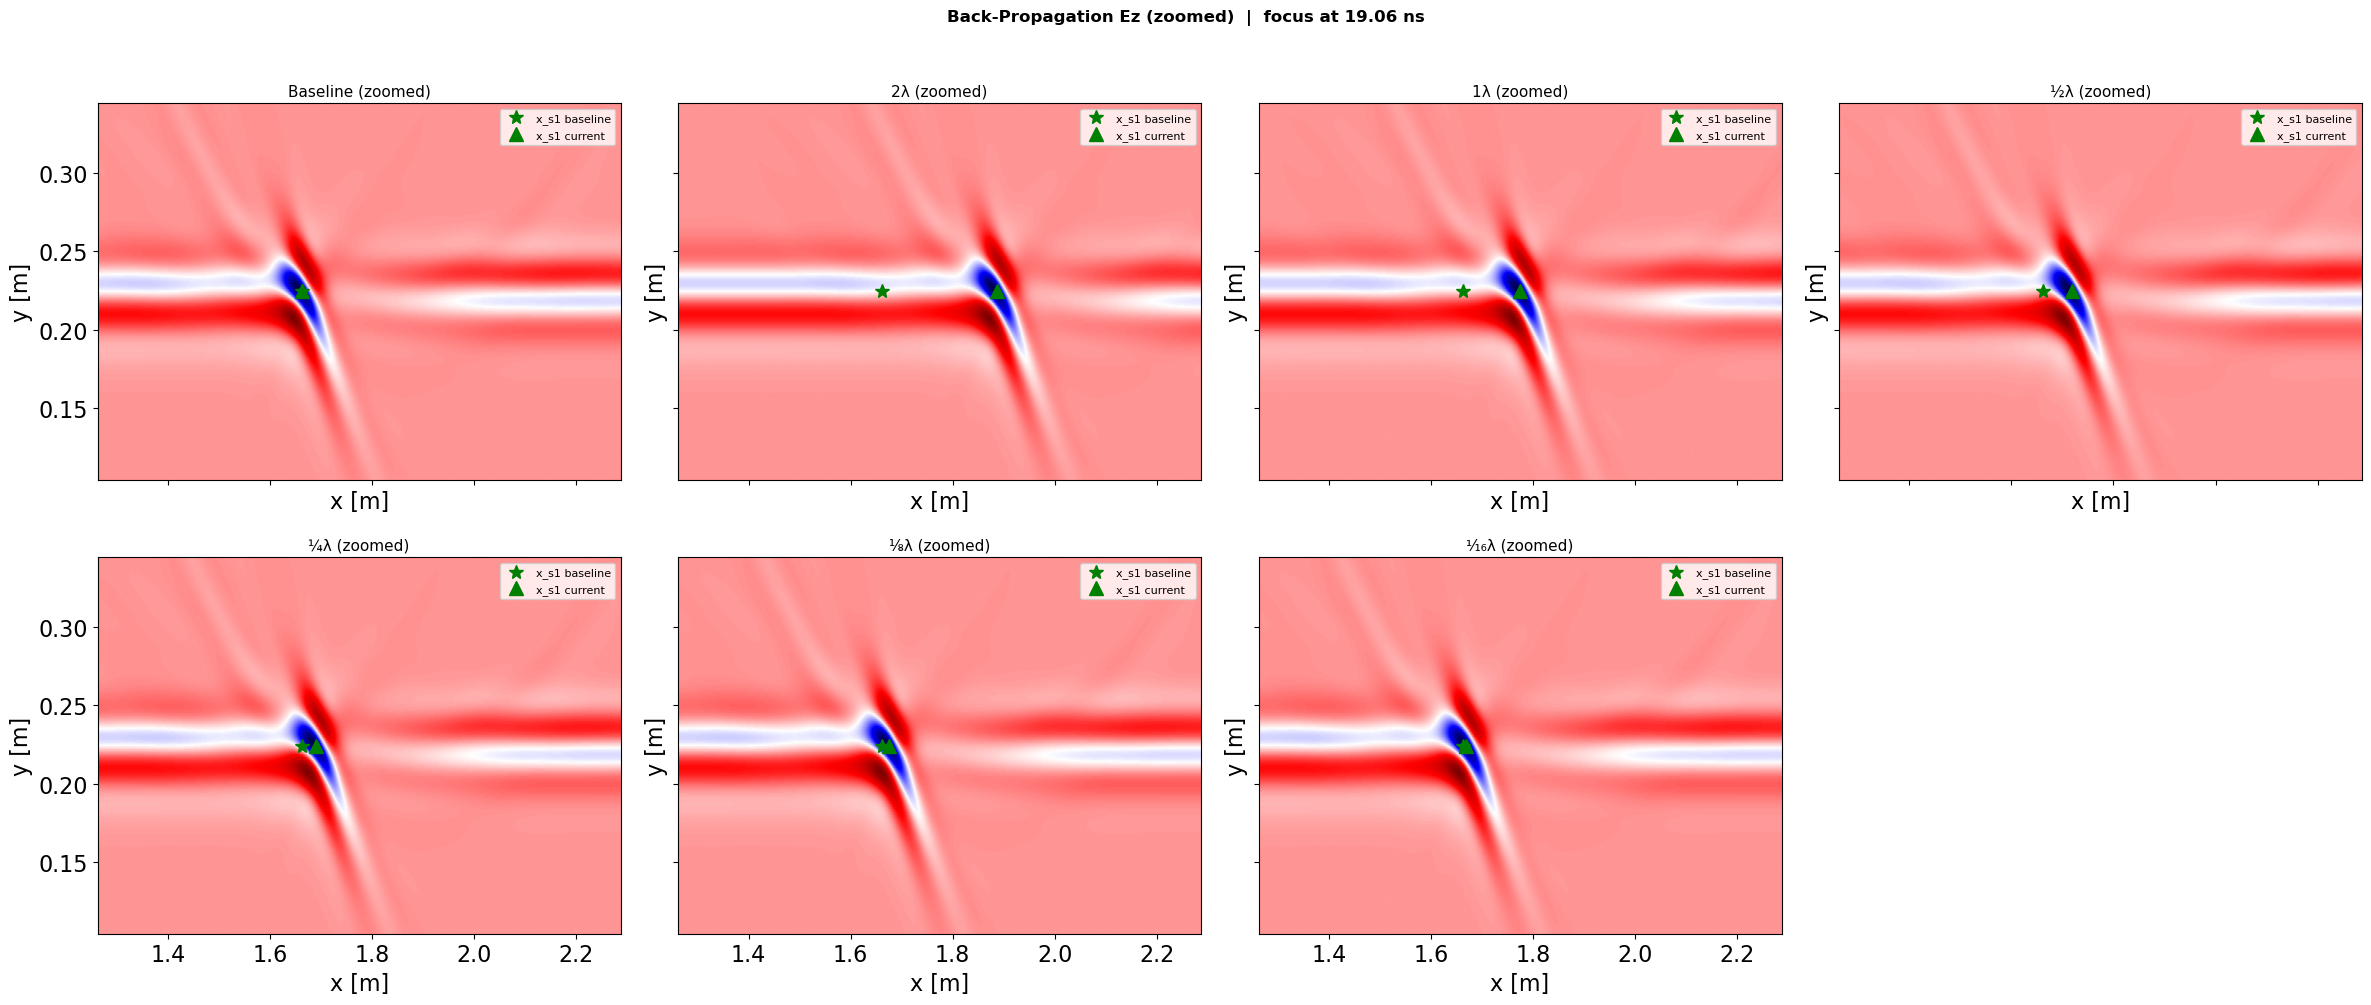

In [18]:
import pyvista

# ── Load focus frame for all 7 datasets ────────────────────────────────────────────
T_ns_bp    = n_t * dt_ns
t_focus_ns = T_ns_bp - t0_ns
t_start_ns = max(0.0, t_focus_ns - SNAP_WIN)
dt_s       = dt_ns * 1e-9
snap_step_ref = max(1, int((T_ns_bp*1e-9 - t_start_ns*1e-9) / (max(1, N_SNAP - 1) * dt_s)))

focus_frames = {}
for i, (label, slug) in enumerate(zip(labels_all, slugs_all)):
    snap_dir   = STUDY_ROOT / 'backprop' / slug / f'backprop_{slug}_snaps'
    snap_files = sorted(
        snap_dir.glob('bp_snap*.vti'),
        key=lambda p: int(p.stem.replace('bp_snap', ''))
    )
    if not snap_files:
        print(f'[{label}] No snapshots in {snap_dir.name} — skipping')
        continue

    snap_times_ns = t_start_ns + np.arange(len(snap_files)) * snap_step_ref * dt_ns
    idx_focus     = min(int(np.argmin(np.abs(snap_times_ns - t_focus_ns))),
                        len(snap_files) - 1)

    snaps_mag, snaps_ez = [], []
    for p in snap_files:
        mesh   = pyvista.read(str(p))
        e_data = np.array(mesh['E-field'])
        snaps_mag.append(np.linalg.norm(e_data, axis=1).reshape(1000, 4000))
        snaps_ez.append(e_data[:, 2].reshape(1000, 4000))

    focus_frames[label] = {
        'mag':      np.stack(snaps_mag)[idx_focus],
        'ez':       np.stack(snaps_ez)[idx_focus],
        't_actual': snap_times_ns[idx_focus],
        'i':        i,
    }
    print(f'[{label}]  {len(snap_files)} snaps  |  focus idx={idx_focus}'
          f'  t={focus_frames[label]["t_actual"]:.3f} ns')

extent_full = [0, 4.0, 0, 1]
margin_x    = 0.4
margin_y    = 0.12

# Zoom x-window fixed to cover the widest (2λ) shift in all shared-axis panels
x_zoom_lo = x_scatterer_1[0] - margin_x
x_zoom_hi = x_scatterer_1[1] + margin_x   # x_scatterer_1[1] = 2λ position

def _add_markers(ax, i):
    ax.plot(x_scatterer_1[0], y_scatterer, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i], y_scatterer, 'g^', ms=10, zorder=5, label='x_s1 current')

# ── |E| magnitude — full extent 2×4 grid ───────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)   # 7 items in 2×4 grid — hide last slot
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    ax.imshow(frame['mag'], aspect='auto', cmap='inferno',
              extent=extent_full, origin='lower')
    _add_markers(ax, frame['i'])
    ax.axhline(y_surface, color='cyan', lw=0.8, ls='--')
    ax.set_title(f'{label}  |  t={frame["t_actual"]:.2f} ns', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
axes.ravel()[0].legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation |E| — All 7 Datasets  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_mag_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── |E| magnitude — zoomed 2×4 grid ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    ax.imshow(frame['mag'], aspect='auto', cmap='inferno',
              extent=extent_full, origin='lower')
    _add_markers(ax, frame['i'])
    ax.set_xlim(x_zoom_lo, x_zoom_hi)
    ax.set_ylim(y_scatterer - margin_y, y_scatterer + margin_y)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation |E| (zoomed)  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_mag_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ez component — full extent 2×4 grid ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    ax.imshow(frame['ez'], aspect='auto', cmap='seismic',
              extent=extent_full, origin='lower')
    _add_markers(ax, frame['i'])
    ax.axhline(y_surface, color='cyan', lw=0.8, ls='--')
    ax.set_title(f'{label}  |  t={frame["t_actual"]:.2f} ns', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
axes.ravel()[0].legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation Ez — All 7 Datasets  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_ez_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Ez component — zoomed 2×4 grid ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)
axes.ravel()[-1].set_visible(False)
for ax, (label, frame) in zip(axes.ravel(), focus_frames.items()):
    ax.imshow(frame['ez'], aspect='auto', cmap='seismic',
              extent=extent_full, origin='lower')
    _add_markers(ax, frame['i'])
    ax.set_xlim(x_zoom_lo, x_zoom_hi)
    ax.set_ylim(y_scatterer - margin_y, y_scatterer + margin_y)
    ax.set_title(f'{label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(f'Back-Propagation Ez (zoomed)  |  focus at {t_focus_ns:.2f} ns',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_all_ez_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


  [saved] FF_017_Back-Propagation__TimeLapse_Differences_Ez_Ez__Ez_baseline.png


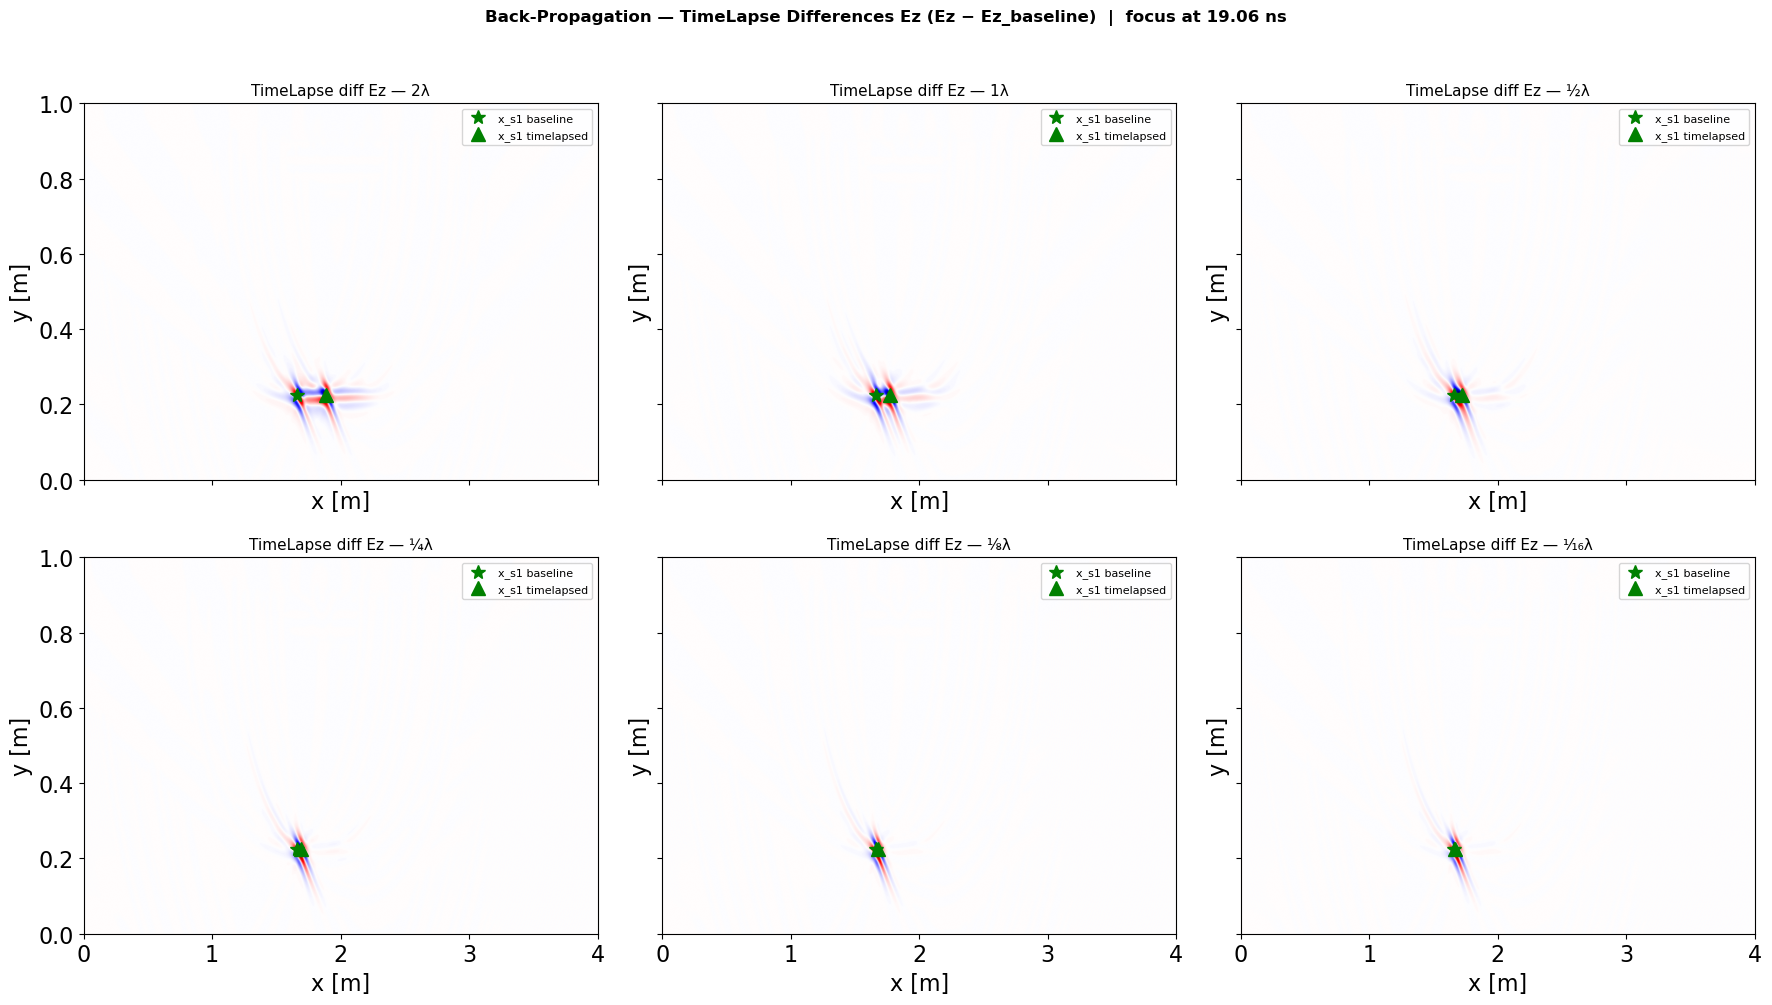

  [saved] FF_018_Back-Propagation__TimeLapse_Differences_Ez_zoomed.png


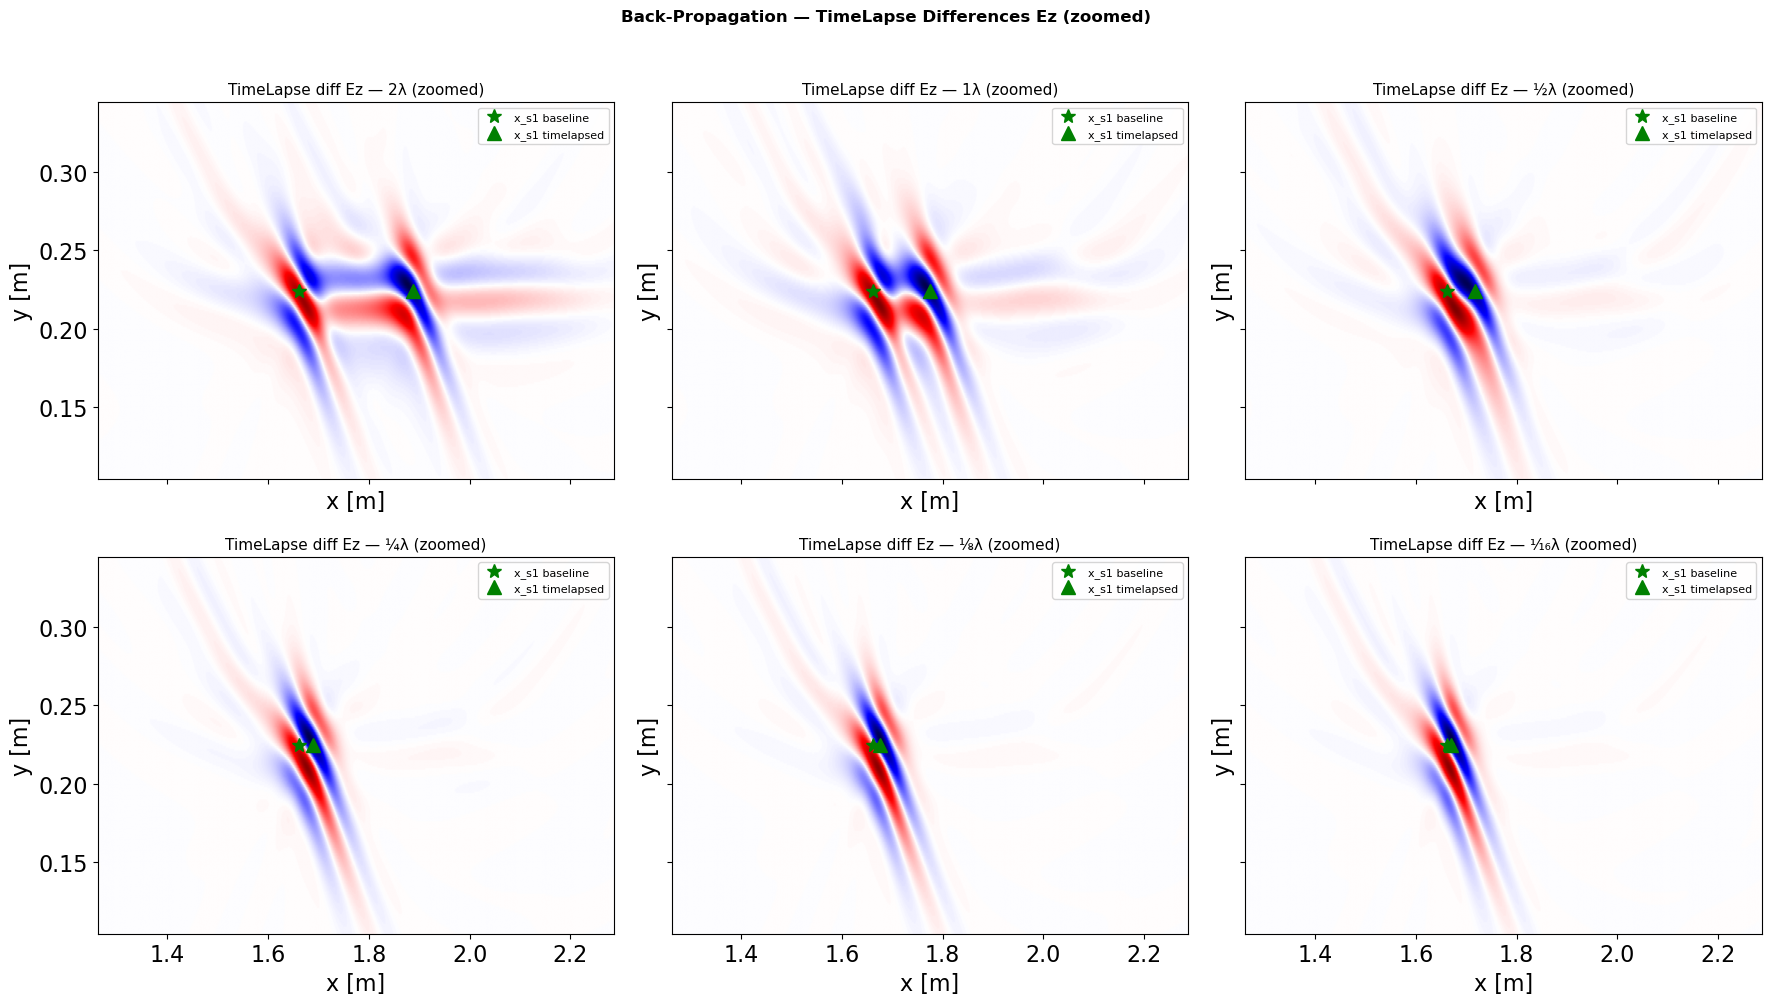

In [19]:
# ── Back-propagation timelapse differences (Ez − Ez_baseline) ─────────────────────
bp_ez_diff = {label: focus_frames[label]['ez'] - focus_frames['Baseline']['ez']
              for label in labels}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), bp_ez_diff.items())):
    vmax = np.percentile(np.abs(diff), 100)
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_full, origin='lower')
    ax.plot(x_scatterer_1[0],     y_scatterer, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], y_scatterer, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_title(f'TimeLapse diff Ez — {label}', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(
    f'Back-Propagation — TimeLapse Differences Ez (Ez − Ez_baseline)  |  focus at {t_focus_ns:.2f} ns',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_timelapse_diff_ez.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Zoomed ────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
for i, (ax, (label, diff)) in enumerate(zip(axes.ravel(), bp_ez_diff.items())):
    vmax = np.percentile(np.abs(diff), 100)
    ax.imshow(diff, aspect='auto', cmap='seismic', vmin=-vmax, vmax=vmax,
              extent=extent_full, origin='lower')
    ax.plot(x_scatterer_1[0],     y_scatterer, 'g*', ms=10, zorder=5, label='x_s1 baseline')
    ax.plot(x_scatterer_1[i + 1], y_scatterer, 'g^', ms=10, zorder=5, label='x_s1 timelapsed')
    ax.set_xlim(x_zoom_lo, x_zoom_hi)
    ax.set_ylim(y_scatterer - margin_y, y_scatterer + margin_y)
    ax.set_title(f'TimeLapse diff Ez — {label} (zoomed)', fontsize=11)
    ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='upper right')
plt.suptitle(
    f'Back-Propagation — TimeLapse Differences Ez (zoomed)',
    fontsize=12, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'backprop_timelapse_diff_ez_zoomed.png', dpi=150, bbox_inches='tight')
plt.show()


# Analysis

[2λ] back-prop diff reprojected  shape=(160, 380)
[1λ] back-prop diff reprojected  shape=(160, 380)
[½λ] back-prop diff reprojected  shape=(160, 380)
[¼λ] back-prop diff reprojected  shape=(160, 380)
[⅛λ] back-prop diff reprojected  shape=(160, 380)
[¹⁄₁₆λ] back-prop diff reprojected  shape=(160, 380)
[¹⁄₃₂λ] back-prop diff reprojected  shape=(160, 380)
  [saved] FF_019_TimeLapse_Migration_Comparison__Signed_Amplitude____f_c15_GH.png


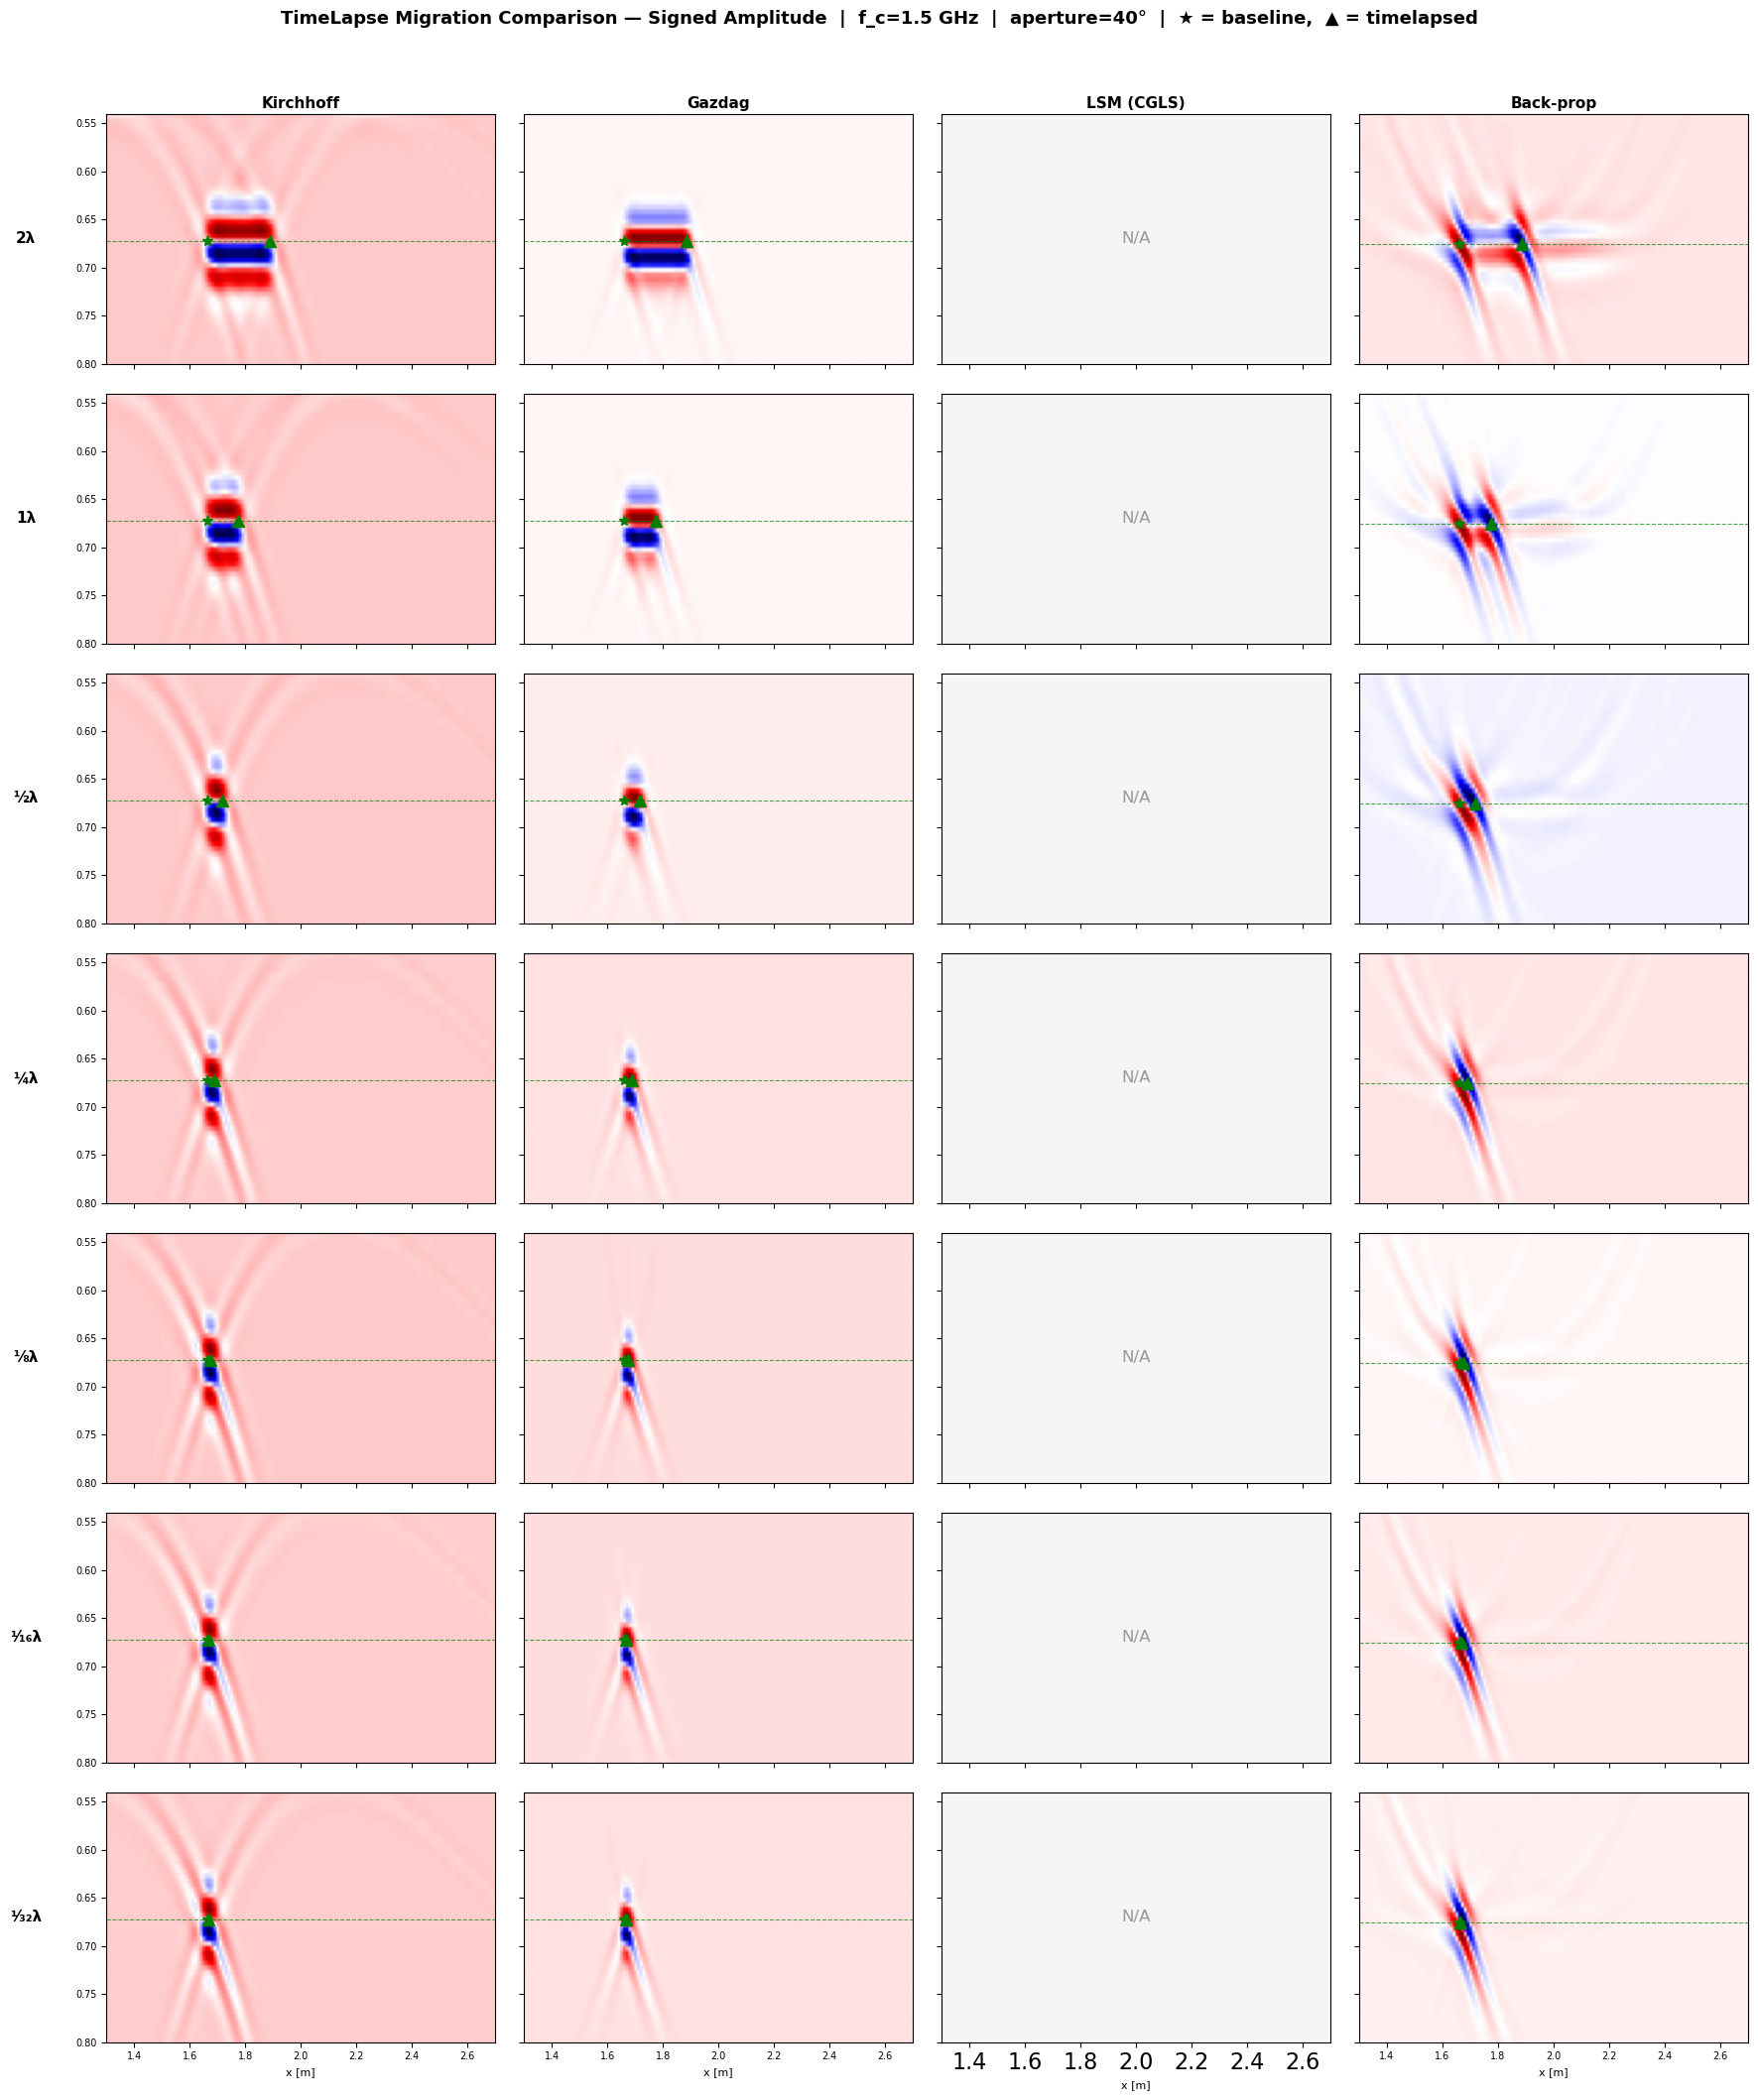

In [20]:
from scipy.signal import hilbert as scipy_hilbert
from scipy.interpolate import RegularGridInterpolator

# ── Collect timelapse difference images: rows = separations, cols = methods ─
methods = ['Kirchhoff', 'Gazdag', 'LSM (CGLS)', 'Back-prop']
n_m, n_s = len(methods), len(labels)
imgs = [[None] * n_m for _ in range(n_s)]

for i, lbl in enumerate(labels):
    # Kirchhoff: use precomputed diff dict; fall back to inline if stale kernel
    try:
        imgs[i][0] = migrated_diff[lbl]
    except (KeyError, NameError):
        if 'Baseline' in migrated and lbl in migrated:
            imgs[i][0] = migrated[lbl] - migrated['Baseline']
    # Gazdag: same pattern
    try:
        imgs[i][1] = migrated_gz_diff[lbl]
    except (KeyError, NameError):
        if 'Baseline' in migrated_gz and lbl in migrated_gz:
            imgs[i][1] = migrated_gz[lbl] - migrated_gz['Baseline']

# LSM (CGLS) — 2λ only (if available)
try:
    imgs[0][2] = m_cgls
except NameError:
    try:
        imgs[0][2] = m_adj
    except NameError:
        pass

# Back-propagation — reproject bp_ez_diff (already in memory) to migration grid
x_ax_bp = np.linspace(0, 4.0, 4000)
y_ax_bp = np.linspace(0, 1.0, 1000)
y_mig   = y_surface - z_img
Yq, Xq  = np.meshgrid(y_mig, x_traces, indexing='ij')

for i, lbl in enumerate(labels):
    if lbl not in bp_ez_diff:
        print(f'[{lbl}] bp_ez_diff missing — skipping')
        continue
    interp = RegularGridInterpolator(
        (y_ax_bp, x_ax_bp), bp_ez_diff[lbl],
        method='linear', bounds_error=False, fill_value=0.0
    )
    imgs[i][3] = interp((Yq, Xq))
    print(f'[{lbl}] back-prop diff reprojected  shape={imgs[i][3].shape}')

# ── Scatterer depth coordinates ──────────────────────────────────────────────
# Kirchhoff/Gazdag: z_top = depth to cylinder top [m]
# Back-prop: gprMax y-axis runs 0–1 m from bottom; convert to depth from surface
bp_z_top = 0.9 - y_scatterer   # = z_scatterer ≈ 0.676 m

# ── Shared plot helper ───────────────────────────────────────────────────────
extent_mig = [x_traces[0], x_traces[-1], z_img[-1], z_img[0]]
xlim = (1.3, 2.7)
ylim = (0.80, 0.54)

def _comparison_figure(envelope=False):
    fig, axes = plt.subplots(n_s, n_m, figsize=(4.5*n_m, 3.0*n_s),
                             sharex=True, sharey=True)
    for i, lbl in enumerate(labels):
        avail = [imgs[i][j] for j in range(n_m) if imgs[i][j] is not None]
        if avail:
            row_vmax = max(
                np.percentile(np.abs(np.abs(scipy_hilbert(a, axis=0)) if envelope else a), 100)
                for a in avail
            )
        else:
            row_vmax = 1.0

        for j, method in enumerate(methods):
            ax  = axes[i, j]
            img = imgs[i][j]

            if i == 0:
                ax.set_title(method, fontsize=11, fontweight='bold', pad=4)
            if j == 0:
                ax.set_ylabel(lbl, fontsize=11, fontweight='bold',
                              rotation=0, labelpad=36, va='center')
            if i == n_s - 1:
                ax.set_xlabel('x [m]', fontsize=8)

            if img is None:
                ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                        ha='center', va='center', fontsize=12, color='#999')
                ax.set_facecolor('#f5f5f5')
                continue

            if envelope:
                disp  = np.abs(scipy_hilbert(img, axis=0))
                cmap, vmin, vmax = 'hot', 0, row_vmax
            else:
                disp  = img
                cmap, vmin, vmax = 'seismic', -row_vmax, row_vmax

            marker_z = bp_z_top if j == 3 else z_top

            ax.imshow(disp, aspect='auto', cmap=cmap,
                      extent=extent_mig, origin='upper')
            ax.plot(x_scatterer_1[0],     marker_z, 'g*', ms=8, zorder=5,
                    label='baseline')
            ax.plot(x_scatterer_1[i + 1], marker_z, 'g^', ms=8, zorder=5,
                    label='timelapsed')
            ax.axhline(marker_z, color='green', ls='--', lw=0.8, alpha=0.7)
            ax.set_xlim(*xlim)
            ax.set_ylim(*ylim)
            ax.tick_params(labelsize=7)

    mode = 'Hilbert Envelope' if envelope else 'Signed Amplitude'
    plt.suptitle(
        f'TimeLapse Migration Comparison — {mode}  |  f_c={f_c_GHz} GHz  '
        f'|  aperture={ANGLE_AP}°  |  ★ = baseline,  ▲ = timelapsed',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    return fig

# ── Figure 1: signed amplitude ───────────────────────────────────────────────
fig1 = _comparison_figure(envelope=False)
fig1.savefig(STUDY_ROOT / 'comparison_timelapse_all_methods.png', dpi=250, bbox_inches='tight')
plt.show()


  [saved] FF_020_Normalised_Lateral_PSF__TimeLapse_Difference_at_True_Scatter.png


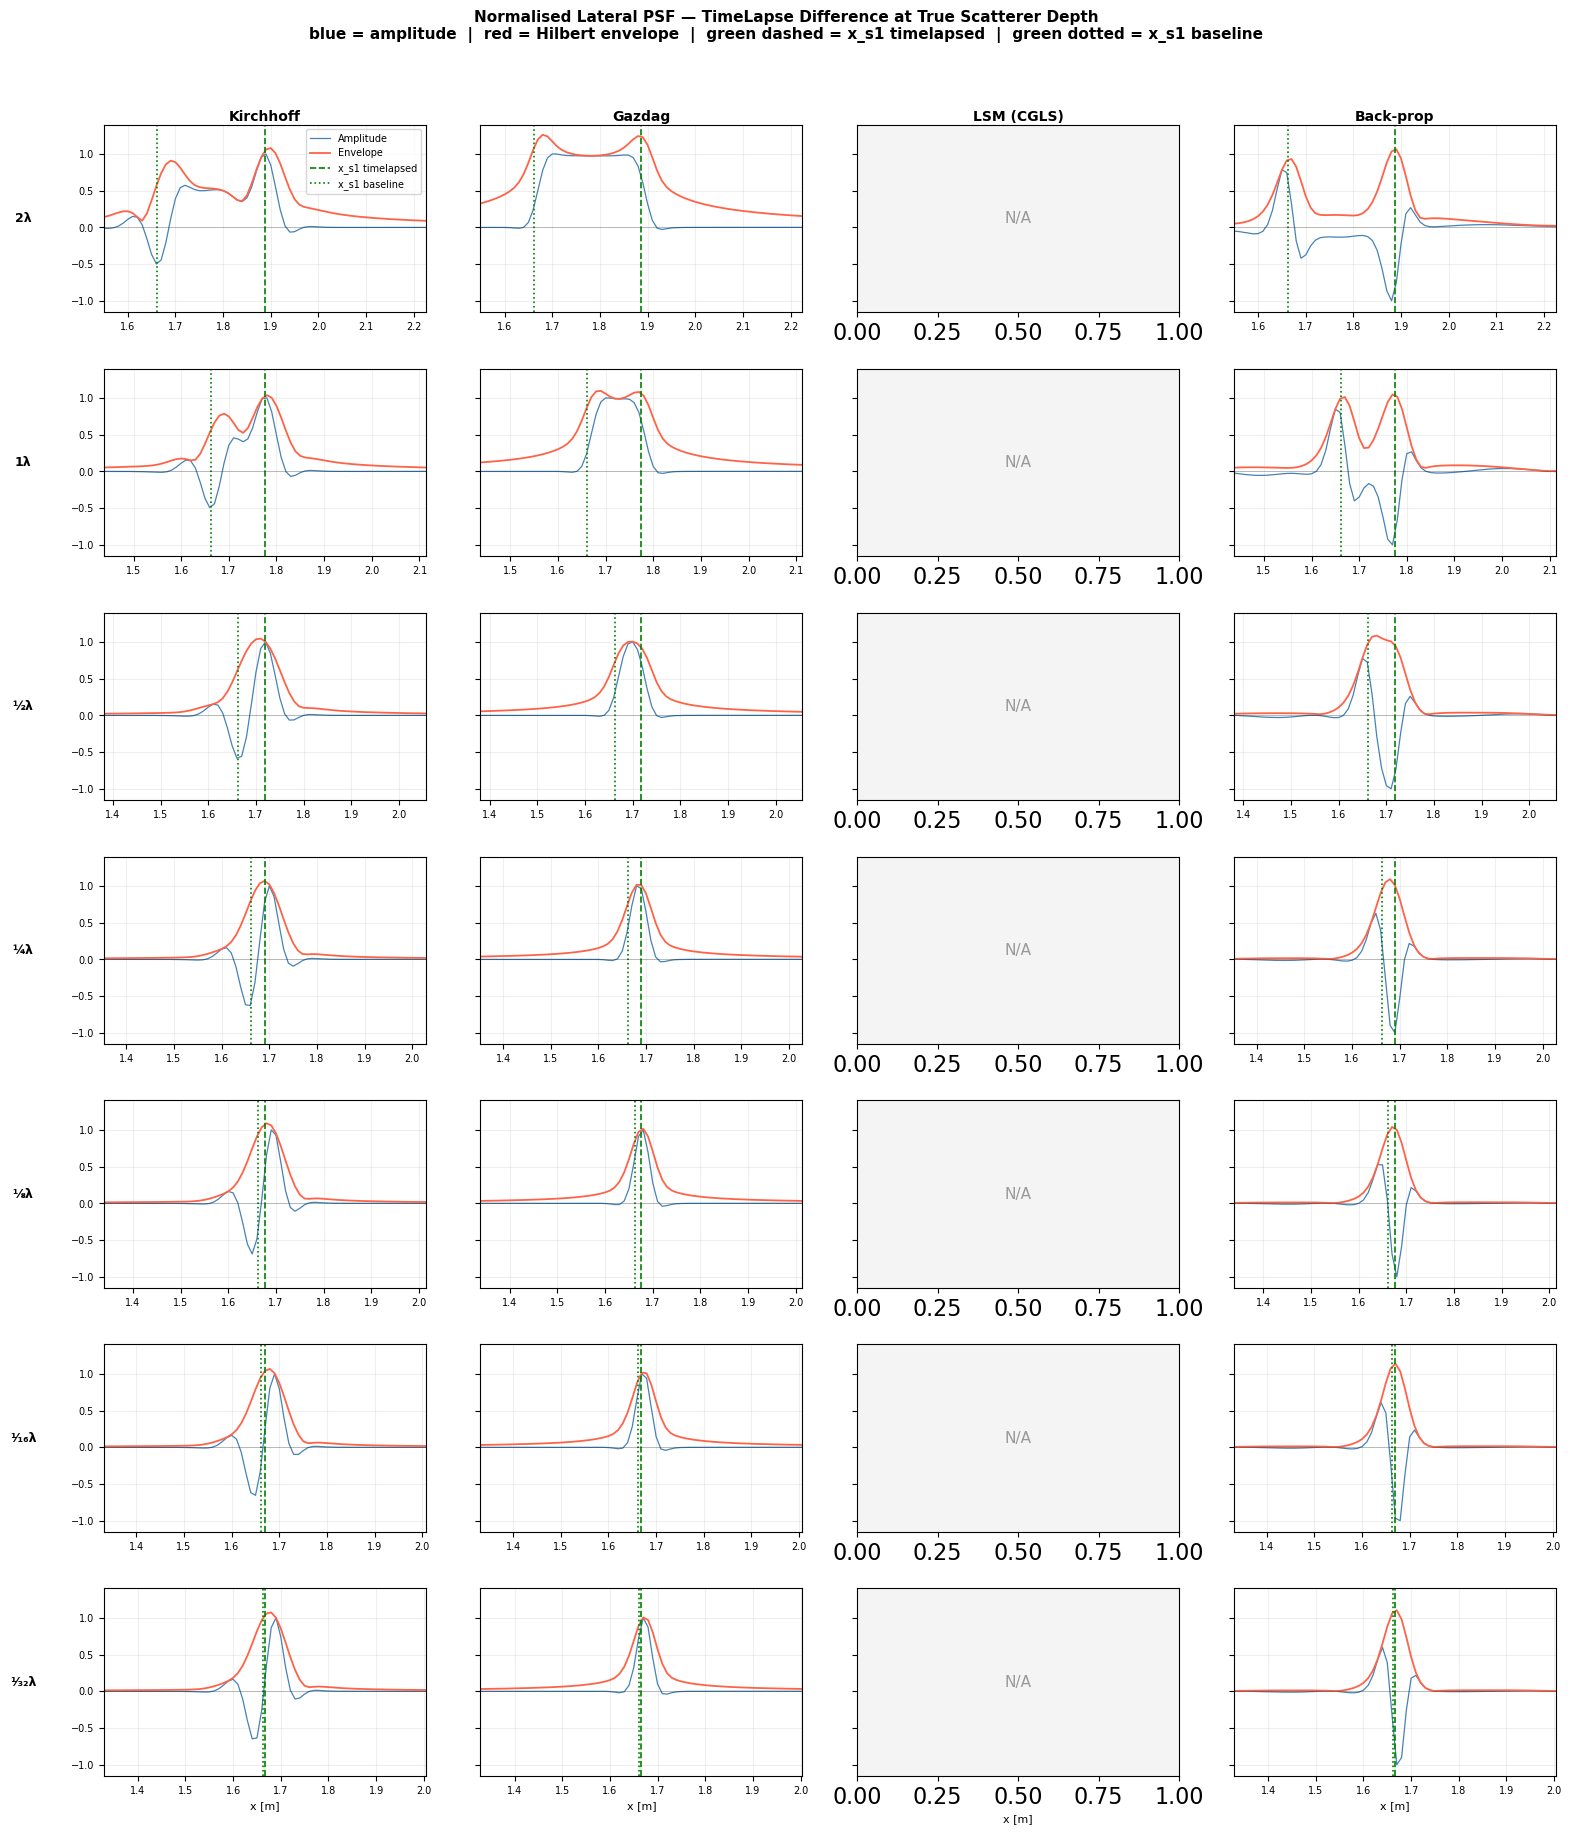

In [21]:
# ── Normalised lateral PSF of timelapse difference at scatterer depth ────────
# Rows = scenario (2λ … ¹⁄₁₆λ), Columns = method
# Each panel: horizontal slice of the timelapse difference image at z = marker_z,
# normalised to its absolute peak, showing how well each method localises the change.
# Blue  = signed amplitude (normalised to peak)
# Red   = Hilbert envelope
# Green dashed = timelapsed scatterer x-position
# Green dotted  = baseline scatterer x-position

x_win = 3.0 * wavelength_ice   # half-window around scatterer x-position [m]

fig_psf, axes_psf = plt.subplots(n_s, n_m,
                                  figsize=(4.0 * n_m, 2.6 * n_s),
                                  sharey=True)

for i, lbl in enumerate(labels):
    for j, method in enumerate(methods):
        ax  = axes_psf[i, j]
        img = imgs[i][j]

        if i == 0:
            ax.set_title(method, fontsize=10, fontweight='bold', pad=3)
        if j == 0:
            ax.set_ylabel(lbl, fontsize=9, fontweight='bold',
                          rotation=0, labelpad=34, va='center')
        if i == n_s - 1:
            ax.set_xlabel('x [m]', fontsize=8)

        if img is None:
            ax.text(0.5, 0.5, 'N/A', transform=ax.transAxes,
                    ha='center', va='center', fontsize=11, color='#999')
            ax.set_facecolor('#f4f4f4')
            continue

        # Depth index closest to the scatterer for this method
        marker_z = bp_z_top if j == 3 else z_top
        iz = int(np.argmin(np.abs(z_img - marker_z)))

        # Lateral profile at scatterer depth, normalised to absolute peak
        profile  = img[iz, :].copy()
        peak     = np.max(np.abs(profile))
        if peak > 0:
            profile /= peak
        envelope = np.abs(scipy_hilbert(profile))

        ax.plot(x_traces, profile,  color='steelblue', lw=0.9, label='Amplitude')
        ax.plot(x_traces, envelope, color='tomato',    lw=1.3, label='Envelope')
        ax.axvline(x_scatterer_1[i + 1], color='green', ls='--', lw=1.2,
                   label='x_s1 timelapsed')
        ax.axvline(x_scatterer_1[0],     color='green', ls=':',  lw=1.2,
                   label='x_s1 baseline')
        ax.axhline(0, color='k', lw=0.4, alpha=0.4)
        ax.set_xlim(x_scatterer_1[i + 1] - x_win, x_scatterer_1[i + 1] + x_win)
        ax.set_ylim(-1.15, 1.4)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)

axes_psf[0, 0].legend(fontsize=7, loc='upper right')

plt.suptitle(
    'Normalised Lateral PSF — TimeLapse Difference at True Scatterer Depth\n'
    'blue = amplitude  |  red = Hilbert envelope  '
    '|  green dashed = x_s1 timelapsed  |  green dotted = x_s1 baseline',
    fontsize=11, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(STUDY_ROOT / 'psf_timelapse_lateral_profiles.png', dpi=200, bbox_inches='tight')
plt.show()


# Save Migrated Results as np arrays dictionary

In [22]:
# ── Build structured numpy representation of all migrated difference results ──────
# imgs[scenario_idx][method_idx] is populated by the analysis cell above.
#   scenarios = labels   →  ["2λ", "1λ", "½λ", "¼λ", "⅛λ", "¹⁄₁₆λ"]
#   methods              →  ["Kirchhoff", "Gazdag", "LSM (CGLS)", "Back-prop"]
#   each image: shape (n_z, n_x) — timelapse difference (monitor − baseline)
#   LSM (CGLS) was run for the 2λ scenario only — None elsewhere.

_ref_shape = imgs[0][0].shape   # (n_z, n_x) reference from Kirchhoff 2λ

def _safe_stack(method_idx):
    planes = []
    for i in range(n_s):
        arr = imgs[i][method_idx]
        planes.append(arr.astype(float) if arr is not None
                      else np.full(_ref_shape, np.nan))
    return np.stack(planes, axis=0)

diff_kirchhoff = _safe_stack(0)   # (6, n_z, n_x)  timelapse differences
diff_gazdag    = _safe_stack(1)
diff_backprop  = _safe_stack(3)
lsm_cgls_2lam  = imgs[0][2].astype(float) if imgs[0][2] is not None else None

# ── Save to disk ──────────────────────────────────────────────────────────────
save_path = STUDY_ROOT / "difference_migrated_results.npz"

payload = dict(
    kirchhoff_diff    = diff_kirchhoff,                                 # (6, n_z, n_x)
    gazdag_diff       = diff_gazdag,
    backprop_diff     = diff_backprop,
    scenarios         = np.array(labels,  dtype="U20"),                 # (6,)  string
    methods           = np.array(methods, dtype="U20"),                 # (4,)  string
    separation_lambda = np.array([2, 1, 0.5, 0.25, 0.125, 0.0625]),    # (6,)  float
    x_traces          = x_traces,                                       # (n_x,) m
    z_img             = z_img,                                          # (n_z,) m
    x_s1              = np.array(x_scatterer_1),                        # (7,) m
    x_s2              = np.float64(x_scatterer_2),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
)
if lsm_cgls_2lam is not None:
    payload["lsm_cgls_2lambda_diff"] = lsm_cgls_2lam   # (n_z, n_x) — 2λ only

np.savez_compressed(save_path, **payload)

# ── In-memory convenience dict ────────────────────────────────────────────────
mig_diff = {
    "Kirchhoff": {lbl: diff_kirchhoff[i] for i, lbl in enumerate(labels)},
    "Gazdag":    {lbl: diff_gazdag[i]    for i, lbl in enumerate(labels)},
    "Back-prop": {lbl: diff_backprop[i]  for i, lbl in enumerate(labels)},
}
if lsm_cgls_2lam is not None:
    mig_diff["LSM (CGLS)"] = {labels[0]: lsm_cgls_2lam}

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Saved → {save_path}")
print(f"\nDifference arrays  (n_scenarios={n_s}, n_z={_ref_shape[0]}, n_x={_ref_shape[1]}):")
for name, arr in [("kirchhoff_diff", diff_kirchhoff),
                  ("gazdag_diff",    diff_gazdag),
                  ("backprop_diff",  diff_backprop)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f"  ({absent} scenario(s) absent → NaN)" if absent else ""
    print(f"  {name:<18}  {arr.shape}{note}")
if lsm_cgls_2lam is not None:
    print(f"  lsm_cgls_diff     {lsm_cgls_2lam.shape}  (2λ only)")

print(f"\nAvailability  ✓ = computed   — = not run")
col_w = 14
print("  " + f"{'':>8}  " + "".join(f"{m:>{col_w}}" for m in methods))
for i, lbl in enumerate(labels):
    row = "  " + f"{lbl:>8}  "
    row += "".join(f"{'✓':>{col_w}}" if imgs[i][j] is not None else f"{'—':>{col_w}}"
                   for j in range(n_m))
    print(row)


Saved → C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study\difference_migrated_results.npz

Difference arrays  (n_scenarios=7, n_z=160, n_x=380):
  kirchhoff_diff      (7, 160, 380)
  gazdag_diff         (7, 160, 380)
  backprop_diff       (7, 160, 380)

Availability  ✓ = computed   — = not run
                 Kirchhoff        Gazdag    LSM (CGLS)     Back-prop
        2λ               ✓             ✓             —             ✓
        1λ               ✓             ✓             —             ✓
        ½λ               ✓             ✓             —             ✓
        ¼λ               ✓             ✓             —             ✓
        ⅛λ               ✓             ✓             —             ✓
     ¹⁄₁₆λ               ✓             ✓             —             ✓
     ¹⁄₃₂λ               ✓             ✓             —             ✓


In [23]:
# ── Save normal (non-difference) migrated results from all methods ────────────
# Stacks all 7 scenarios (Baseline + 6 shifts) from migrated, migrated_gz,
# and focus_frames (back-prop), saving to migrated_results.npz.
# Index 0 = Baseline, indices 1-6 = shift scenarios matching labels_all[1:].

# ── Kirchhoff & Gazdag: direct stack over labels_all ─────────────────────────
kirchhoff_all = np.stack([migrated[lbl].astype(float)    for lbl in labels_all], axis=0)  # (7, n_z, n_x)
gazdag_all    = np.stack([migrated_gz[lbl].astype(float) for lbl in labels_all], axis=0)

# ── Back-prop: reproject focus_frames ez onto migration grid ──────────────────
x_ax_bp = np.linspace(0, 4.0, 4000)
y_ax_bp = np.linspace(0, 1.0, 1000)
y_mig   = y_surface - z_img
Yq, Xq  = np.meshgrid(y_mig, x_traces, indexing='ij')

from scipy.interpolate import RegularGridInterpolator as _RGI
backprop_planes = []
for lbl in labels_all:
    if lbl in focus_frames:
        interp = _RGI((y_ax_bp, x_ax_bp), focus_frames[lbl]['ez'],
                      method='linear', bounds_error=False, fill_value=0.0)
        backprop_planes.append(interp((Yq, Xq)).astype(float))
    else:
        backprop_planes.append(np.full((len(z_img), len(x_traces)), np.nan))
        print(f'[{lbl}] focus_frames missing — filled with NaN')
backprop_all = np.stack(backprop_planes, axis=0)  # (7, n_z, n_x)

# ── Save to disk ──────────────────────────────────────────────────────────────
save_path_mig = STUDY_ROOT / "migrated_results.npz"

np.savez_compressed(
    save_path_mig,
    kirchhoff         = kirchhoff_all,                                   # (9, n_z, n_x)
    gazdag            = gazdag_all,
    backprop          = backprop_all,
    scenarios         = np.array(labels_all, dtype="U20"),               # (9,)  Baseline + 8 shifts
    separation_lambda = np.array([0, 2, 1, 0.5, 0.25, 0.125, 0.0625, 0.03125]),  # (9,)  0 = baseline
    x_traces          = x_traces,
    z_img             = z_img,
    x_s1              = np.array(x_scatterer_1),
    x_s2              = np.float64(x_scatterer_2),
    z_scatterer       = np.float64(z_scatterer),
    z_top             = np.float64(z_top),
)

print(f"Saved → {save_path_mig}")
print(f"\nStacked arrays  (n_scenarios=9, n_z={kirchhoff_all.shape[1]}, n_x={kirchhoff_all.shape[2]}):")
for name, arr in [("kirchhoff",  kirchhoff_all),
                  ("gazdag",     gazdag_all),
                  ("backprop",   backprop_all)]:
    absent = int(np.isnan(arr).all(axis=(1, 2)).sum())
    note   = f"  ({absent} scenario(s) absent → NaN)" if absent else ""
    print(f"  {name:<12}  {arr.shape}{note}")
print(f"\nUsage examples:")
print(f"  d = np.load(str(STUDY_ROOT / 'migrated_results.npz'), allow_pickle=False)")
print(f"  d['kirchhoff'][0]   # Kirchhoff Baseline → shape (n_z, n_x)")
print(f"  d['gazdag'][3]      # Gazdag ¼λ          → shape (n_z, n_x)")


Saved → C:\Users\Administrator\OneDrive\Thesis\TimeLapse_Notebooks\fluidflow_study\migrated_results.npz

Stacked arrays  (n_scenarios=9, n_z=160, n_x=380):
  kirchhoff     (8, 160, 380)
  gazdag        (8, 160, 380)
  backprop      (8, 160, 380)

Usage examples:
  d = np.load(str(STUDY_ROOT / 'migrated_results.npz'), allow_pickle=False)
  d['kirchhoff'][0]   # Kirchhoff Baseline → shape (n_z, n_x)
  d['gazdag'][3]      # Gazdag ¼λ          → shape (n_z, n_x)
